# Freddie Mac — 10F CatBoost SHAP analysis without HARP

This notebook explains the selected, fitted 10F CatBoost model. It removes `HARP_High_Leverage` and retains `DTI_Missing`. It reconstructs the original stratified 80/20 split, restores categorical dtypes, and uses the existing `my_diag` SHAP workflow. The plots show all 10 variables (`cum_ratio=1.0`), including low-ranked features. No model is retrained.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split
from helpers import *

PROJECT_ROOT = Path(
    r"C:\Users\itwill\Desktop\study\코딩공부\프로젝트"
    r"\The Single Family Loan-Level Dataset (SFLLD) - 6"
)
PROJECT_NAME = "SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams"
project_name = str(PROJECT_ROOT / "notebooks" / PROJECT_NAME / "importance" / "no_harp_10F")
MODEL_PATH = PROJECT_ROOT / "notebooks" / PROJECT_NAME / "importance" / "catboost_no_harp_10F_fixed.pkl"
DATA_PATH = PROJECT_ROOT / "data" / "output" / "model_ready" / "SFLLD_regular_PIT_train_ML_ready.parquet"
shap_dir = Path(project_name) / "shap"
RANDOM_STATE = 3217
cum_ratio = 1.0

for path in [MODEL_PATH, DATA_PATH]:
    if not path.is_file():
        raise FileNotFoundError(f"File not found: {path}")
shap_dir.mkdir(parents=True, exist_ok=True)

estimator = my_ml.load_model(MODEL_PATH)
df = pd.read_parquet(DATA_PATH)
print("Model:", MODEL_PATH)
print("Dataset:", DATA_PATH, df.shape)
print("SHAP output:", shap_dir)

Model: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\catboost_no_harp_10F_fixed.pkl
Dataset: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready\SFLLD_regular_PIT_train_ML_ready.parquet (160003, 56)
SHAP output: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\no_harp_10F\shap


In [ ]:
FEATURES_10F = [
    "FICO_Score", "Original_DTI", "Original_CLTV", "Original_Interest_Rate",
    "Number_of_Borrowers", "DTI_Missing",
    "Spatial_Cluster_Region", "Housing_HPI_Growth_12M",
    "BLS_Unemployment_Rate_Change_12M_Final", "Regular_MSA_Macro_Cluster_A",
]
CATEGORICAL_10F = [
    "DTI_Missing", "Spatial_Cluster_Region",
    "Regular_MSA_Macro_Cluster_A",
]
missing = [c for c in FEATURES_10F + ["Target_24M"] if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

df = my_qtcheck.set_type(df, as_category=CATEGORICAL_10F)
X = df[FEATURES_10F].copy()
y = df["Target_24M"].copy()
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
assert x_train.columns.tolist() == FEATURES_10F
assert not x_train.isna().any().any()
for col in CATEGORICAL_10F:
    assert isinstance(x_train[col].dtype, pd.CategoricalDtype), (col, x_train[col].dtype)

print("Train:", x_train.shape, "Test:", x_test.shape)
print("Categorical features:", CATEGORICAL_10F)
print(x_train[CATEGORICAL_10F].dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 160003 entries, 0 to 160002
Data columns (total 56 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Loan_ID                                 160003 non-null  str           
 1   FICO_Score                              160003 non-null  float64       
 2   First_Payment_Date                      160003 non-null  datetime64[us]
 3   First_Time_Homebuyer                    160003 non-null  int64         
 4   Maturity_Date                           160003 non-null  datetime64[us]
 5   MSA                                     160003 non-null  int64         
 6   MI_Percentage                           160003 non-null  float64       
 7   Number_of_Units                         160003 non-null  int64         
 8   Occupancy_Status                        160003 non-null  int64         
 9   Original_CLTV                           160003 n

## Global and local explanations

This notebook explains the fitted 10F model after removing `HARP_High_Leverage`. SHAP describes the retained features and cannot attribute effects to the removed feature. Compare predictive metrics with the 11F experiment to assess the removal.

In [ ]:
# Display names are intentionally descriptive; no undocumented category-code mapping is assumed.
column_means = {
    "FICO_Score": "FICO score",
    "Original_DTI": "Original debt-to-income ratio",
    "Original_CLTV": "Original combined loan-to-value ratio",
    "Original_Interest_Rate": "Original interest rate",
    "Number_of_Borrowers": "Number of borrowers",
    "DTI_Missing": "DTI originally missing",
    "Spatial_Cluster_Region": "Spatial cluster region",
    "Housing_HPI_Growth_12M": "12-month house-price growth",
    "BLS_Unemployment_Rate_Change_12M_Final": "12-month unemployment-rate change",
    "Regular_MSA_Macro_Cluster_A": "MSA macro cluster A",
}

summary = my_diag.shap_analysis(project_name, estimator, x_train)
display(summary)
print("Saved SHAP files:", [p.name for p in sorted(shap_dir.iterdir()) if p.is_file()])

모델: CatBoostClassifier / explainer: TreeExplainer
설명 대상: 128002행 × 10변수 / base value: -5.8940 / SHAP 값의 단위: 로그오즈
설명 대상 클래스: 1 (index=1)
SHAP 분석 결과 저장 완료 → C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\no_harp_10F\shap\catboostclassifier_shap.pkl


,mean_abs_shap,ratio,cum_ratio,mean_shap,std_shap,direction,cv,stability
Feature,,,,,,,,
FICO_Score,0.637318,0.282608,0.282608,0.000522,0.740890,증가,1.162512,비선형/불안정
Number_of_Borrowers,0.471988,0.209295,0.491904,0.000183,0.473053,증가,1.002257,비선형/불안정
Original_Interest_Rate,0.243415,0.107939,0.599843,-0.000799,0.294402,감소,1.209464,비선형/불안정
Original_CLTV,0.201247,0.089240,0.689082,0.000377,0.264395,증가,1.313782,비선형/불안정
Original_DTI,0.176757,0.078380,0.767462,-0.001142,0.227112,감소,1.284882,비선형/불안정
Spatial_Cluster_Region,0.160628,0.071228,0.838690,-0.011130,0.188050,감소,1.170717,비선형/불안정
BLS_Unemployment_Rate_Change_12M_Final,0.134004,0.059422,0.898112,-0.001284,0.181735,감소,1.356199,비선형/불안정
Regular_MSA_Macro_Cluster_A,0.109275,0.048456,0.946568,0.007416,0.114785,증가,1.050424,비선형/불안정
DTI_Missing,0.068658,0.030445,0.977013,0.001100,0.116204,증가,1.692508,비선형/불안정


Saved SHAP files: ['catboostclassifier_shap.pkl']


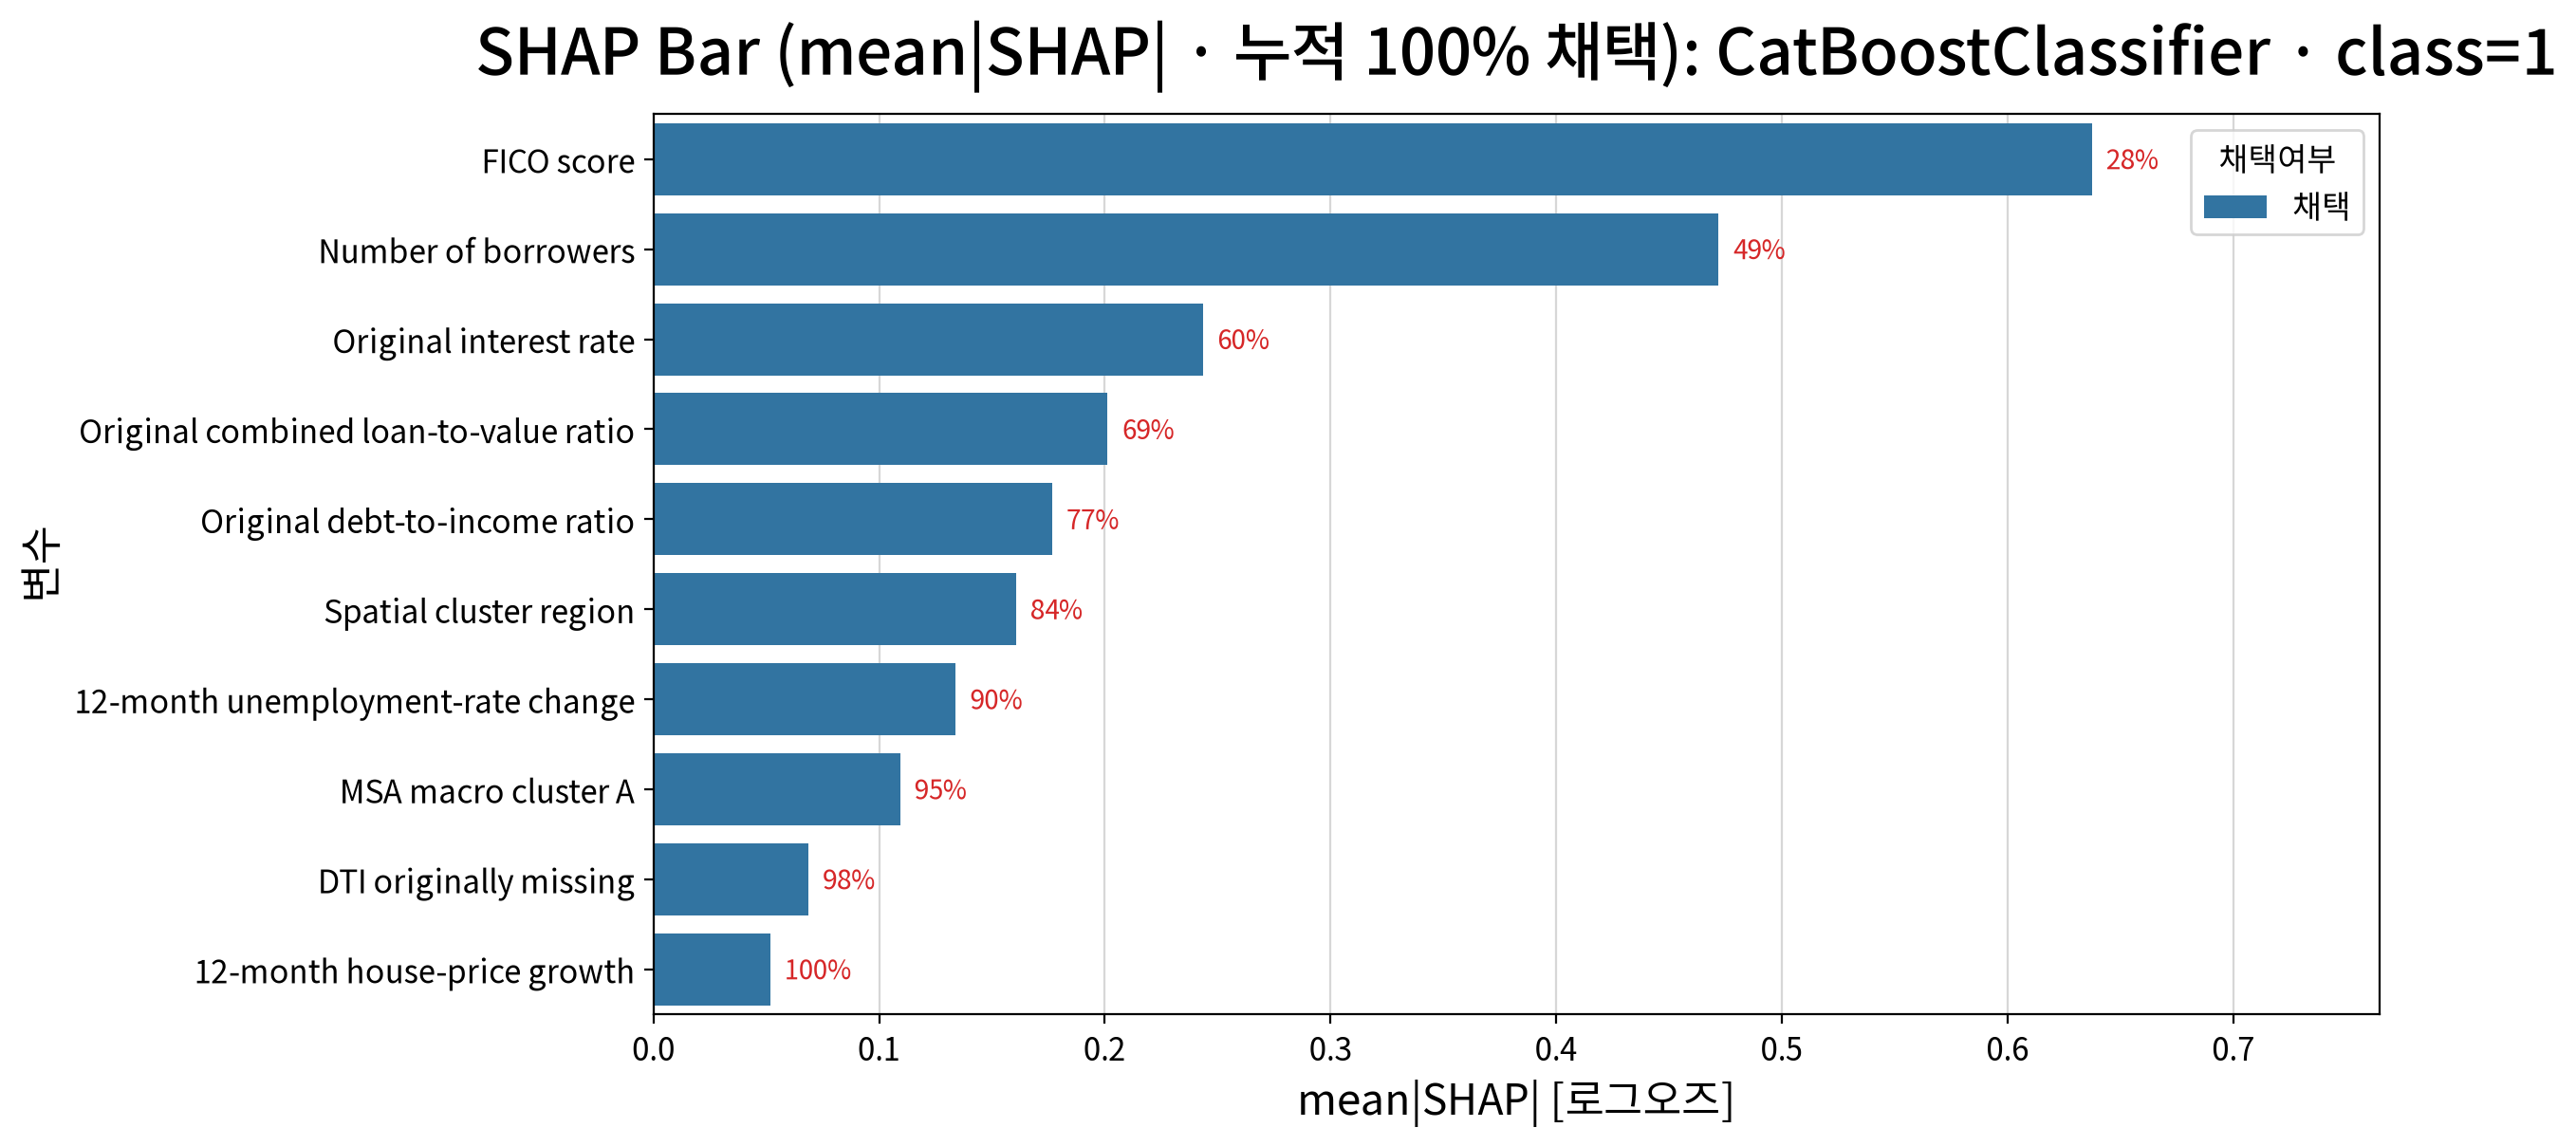

In [ ]:
my_diag.shap_bar_plot(summary, cum_ratio=cum_ratio, column_means=column_means)

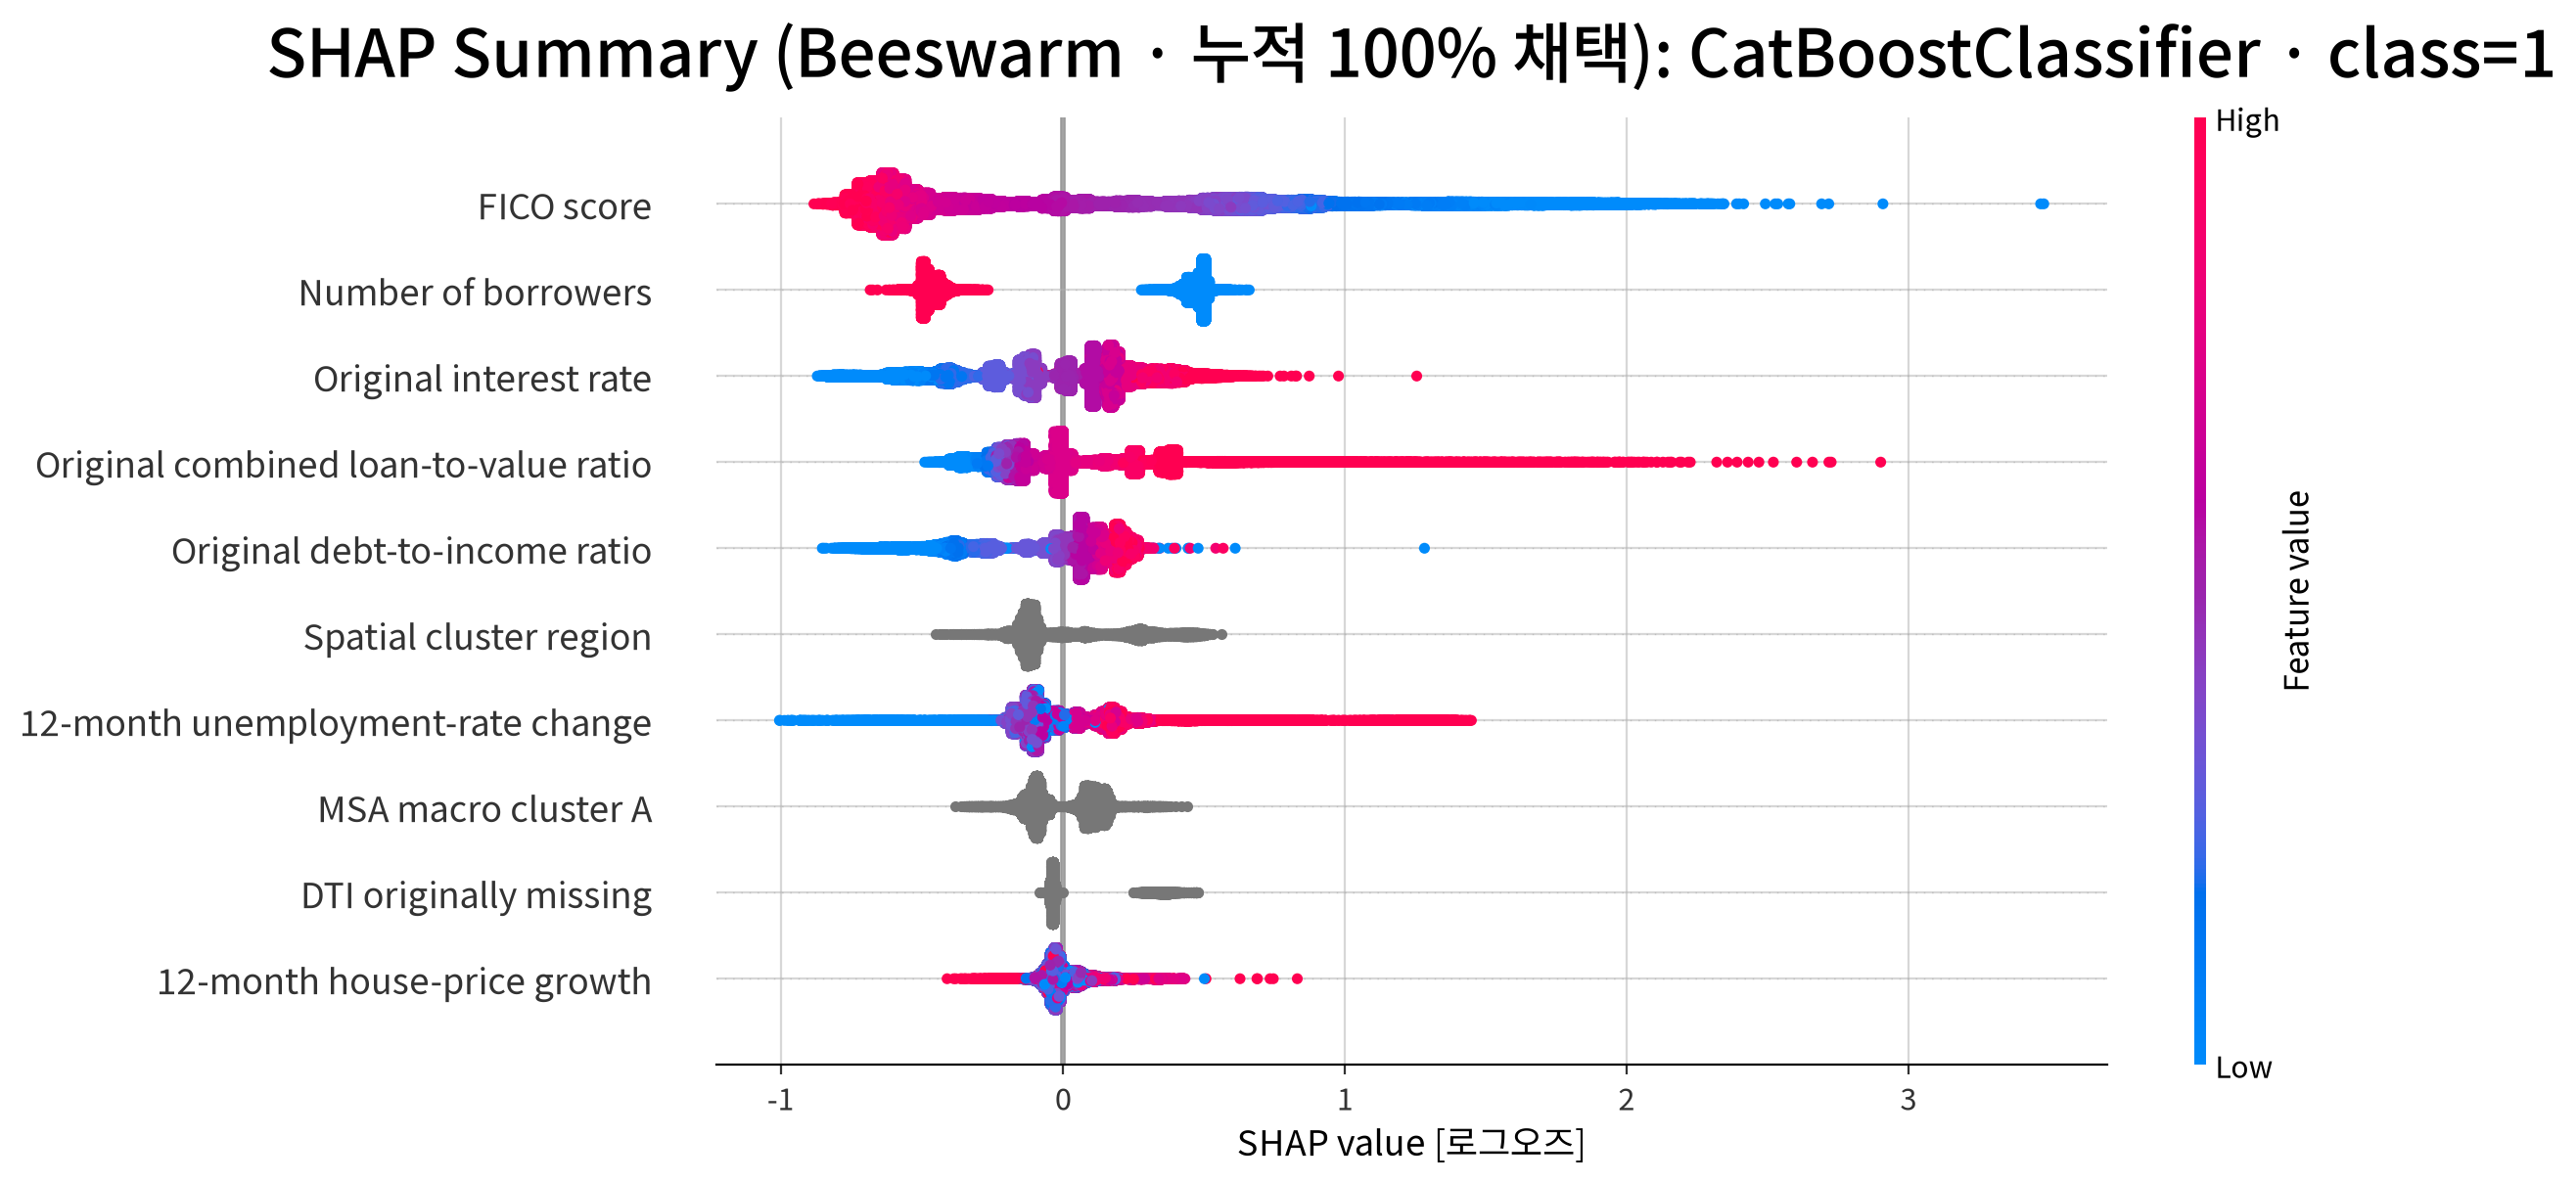

In [ ]:
my_diag.shap_summary_plot(summary, cum_ratio=cum_ratio, column_means=column_means)

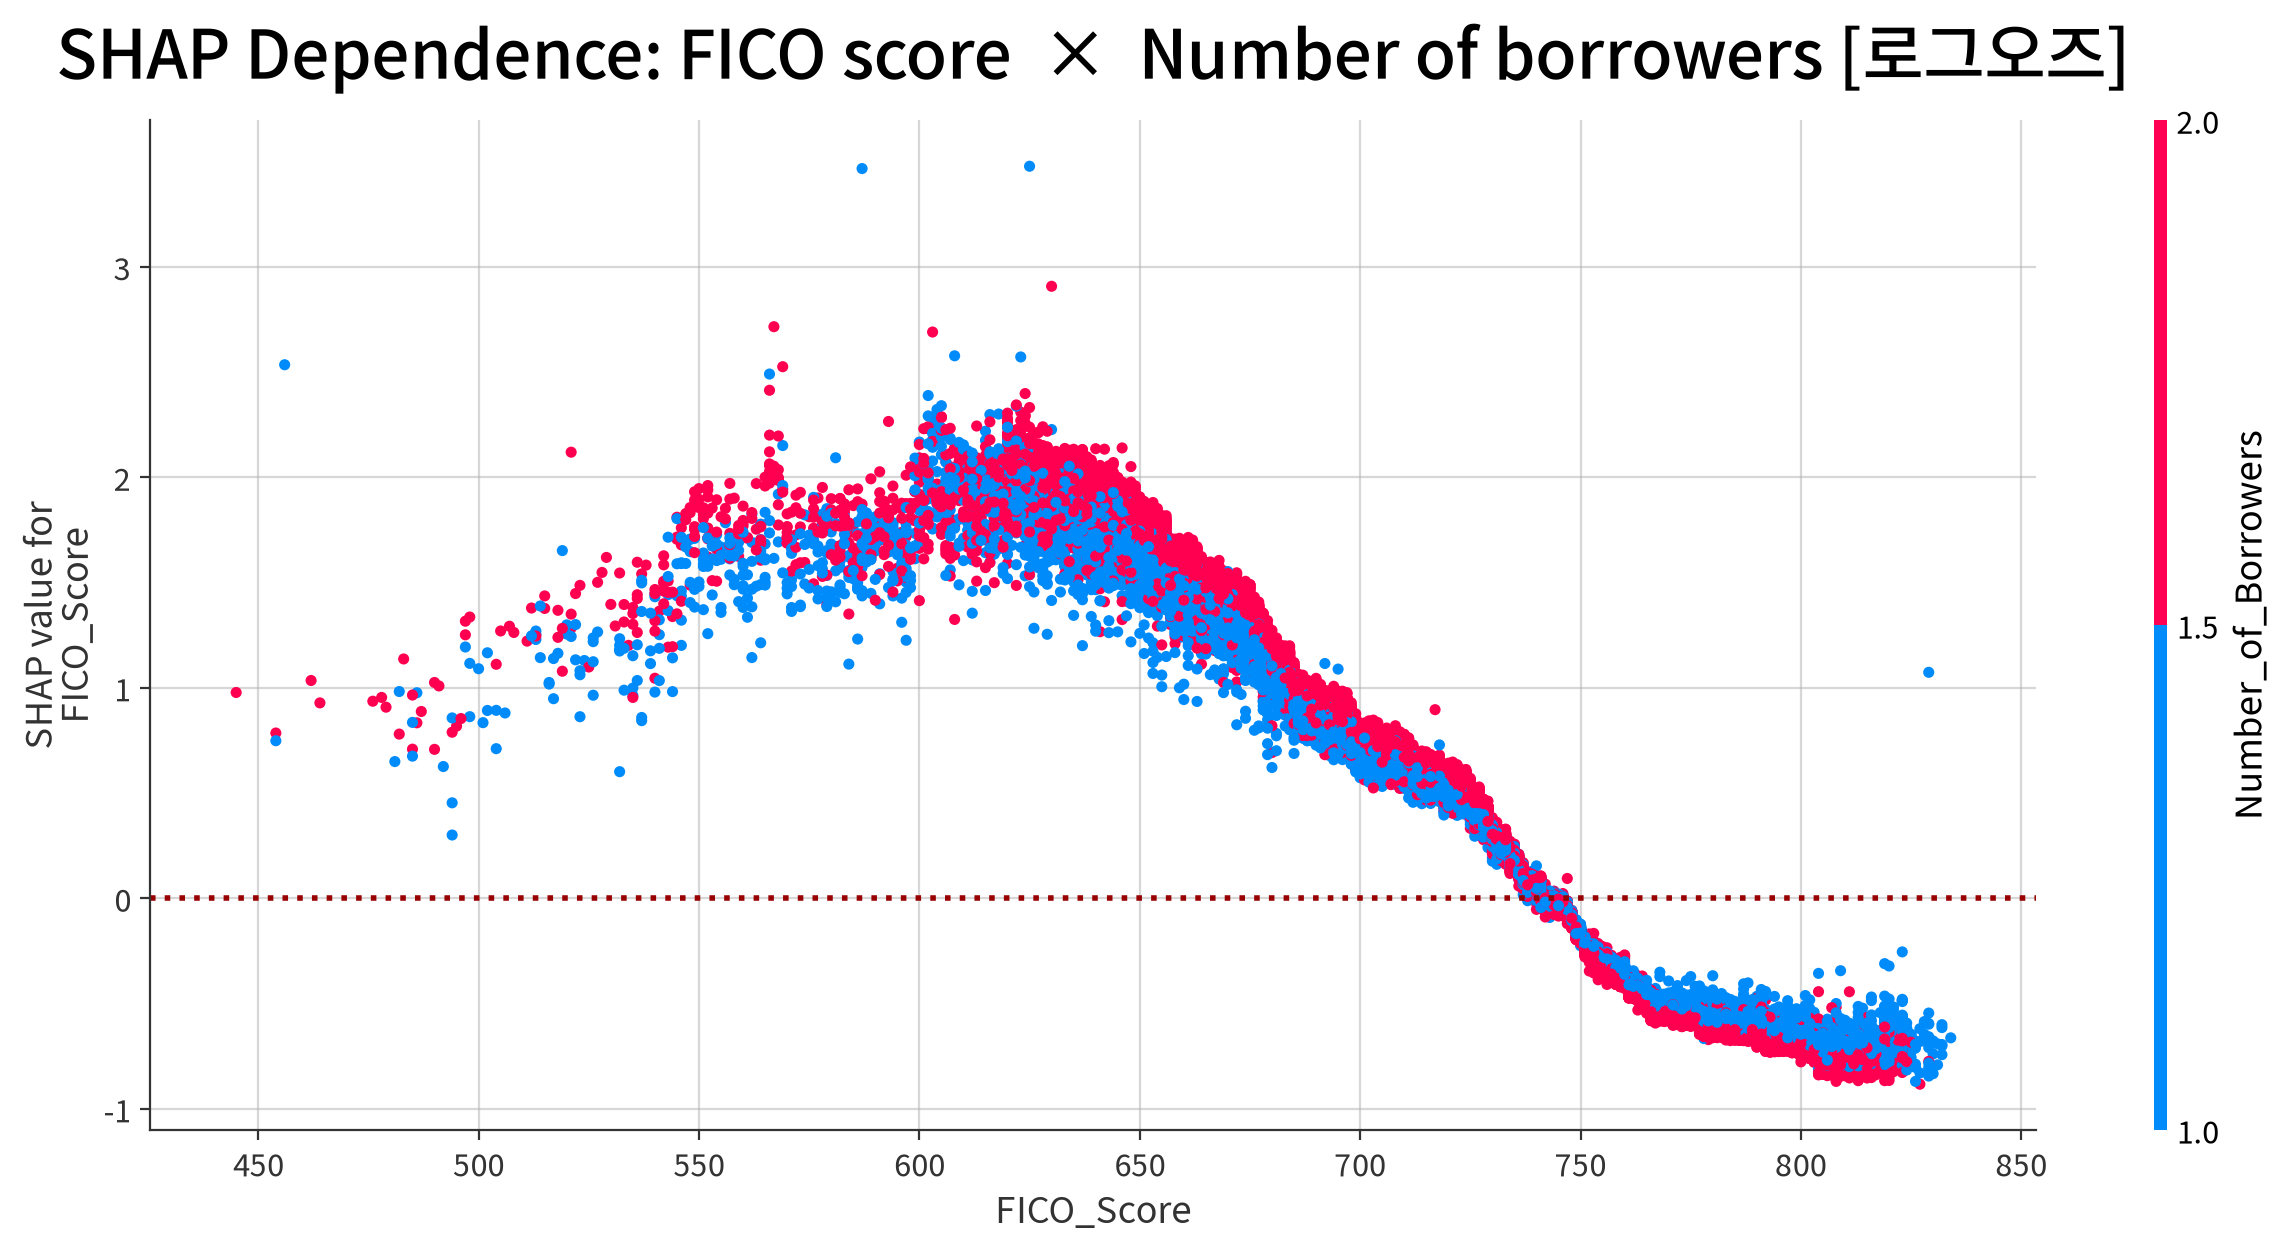

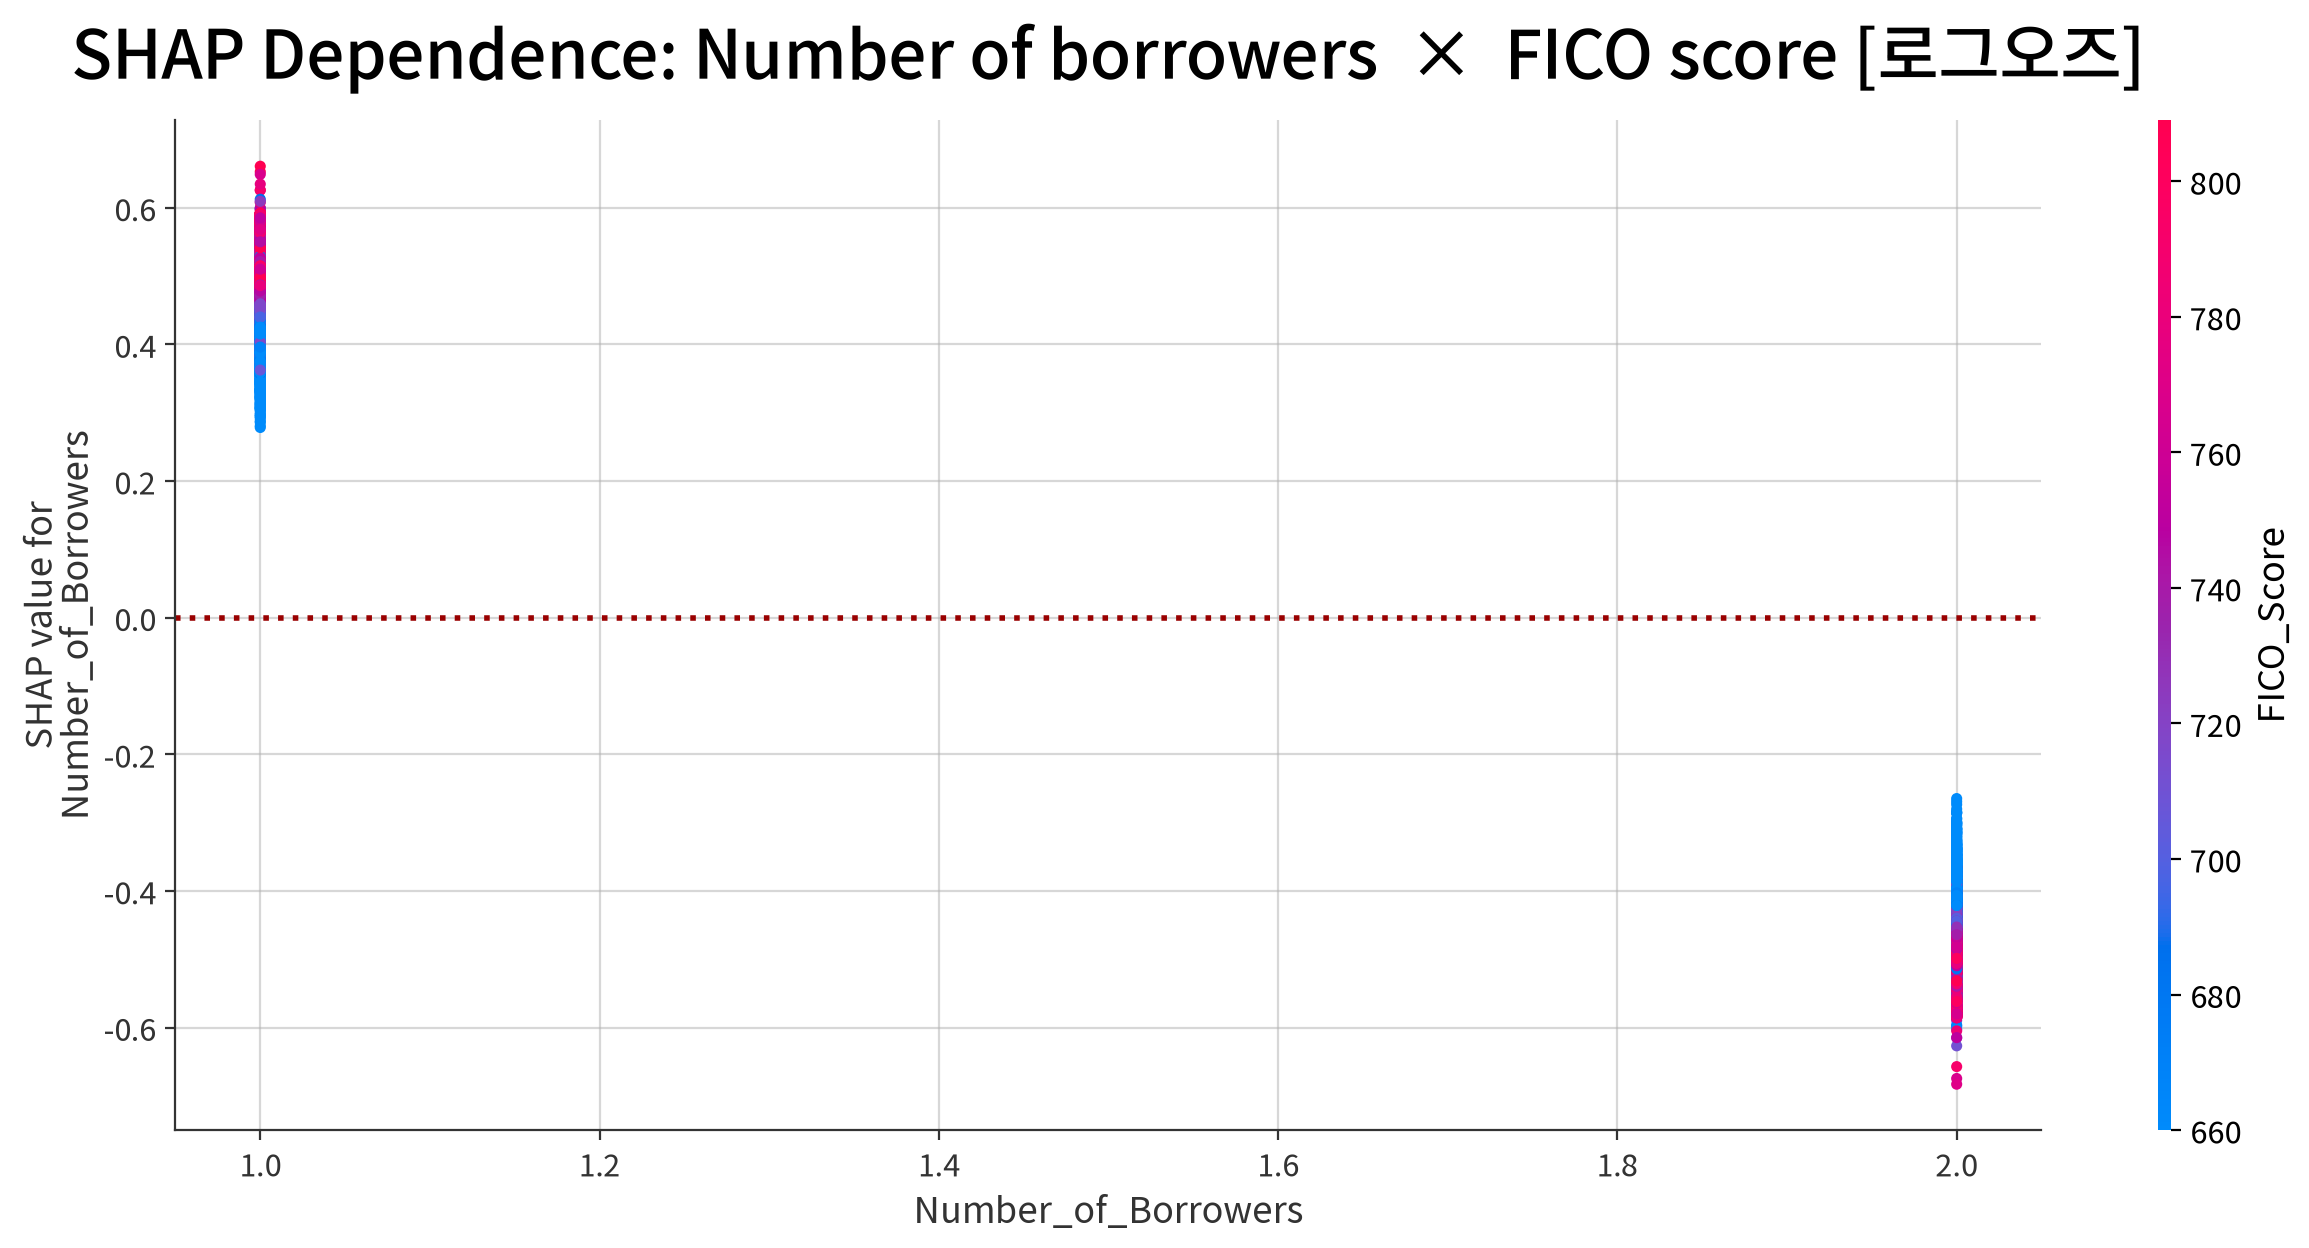

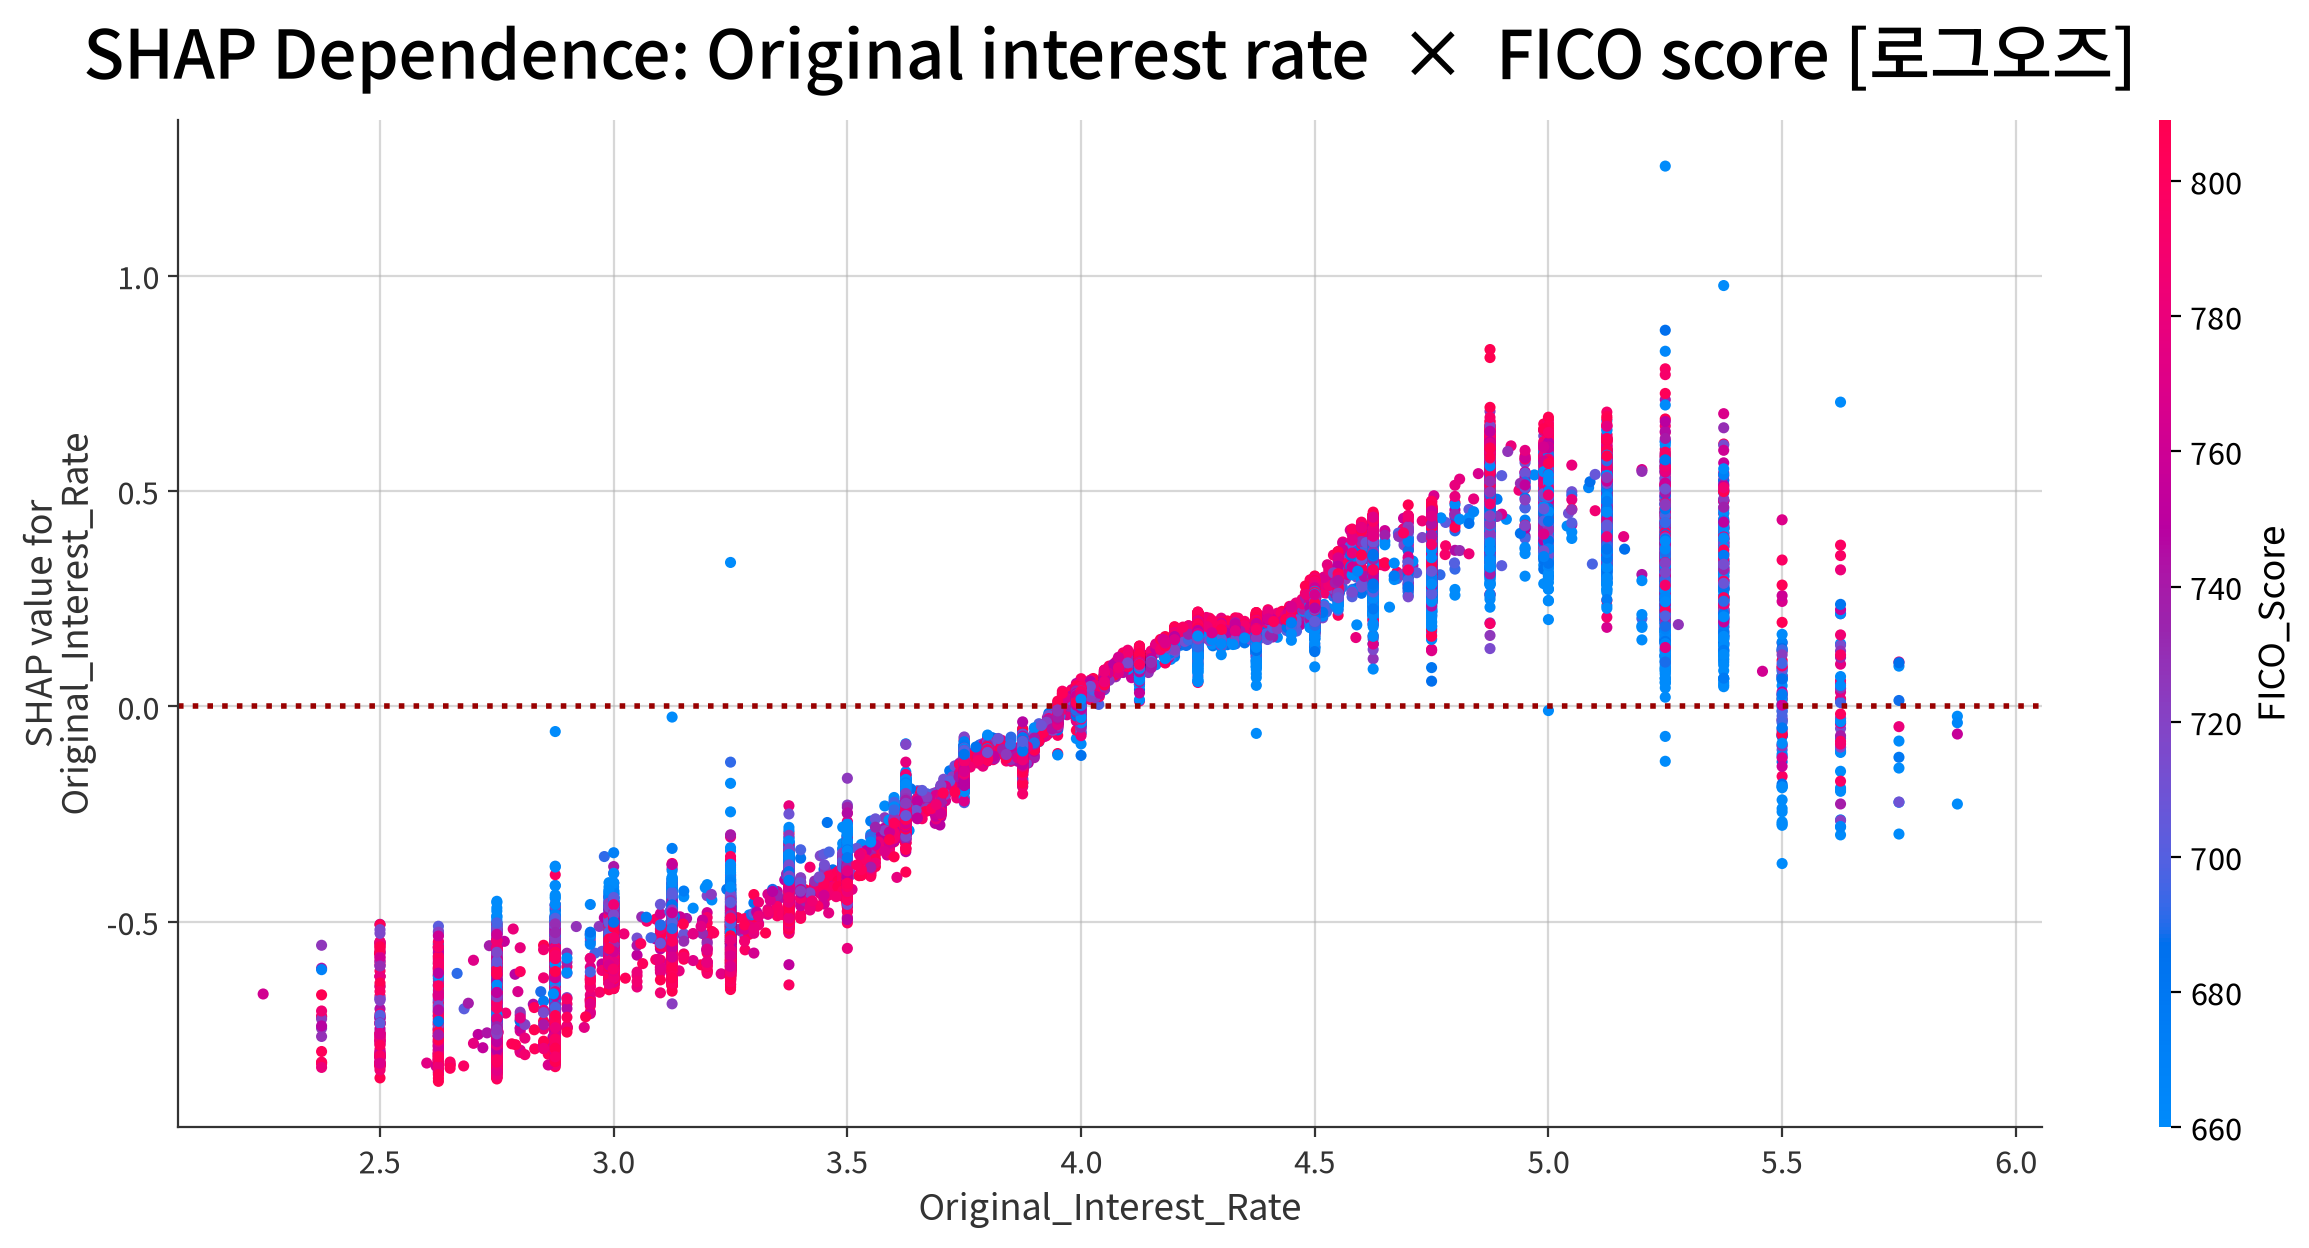

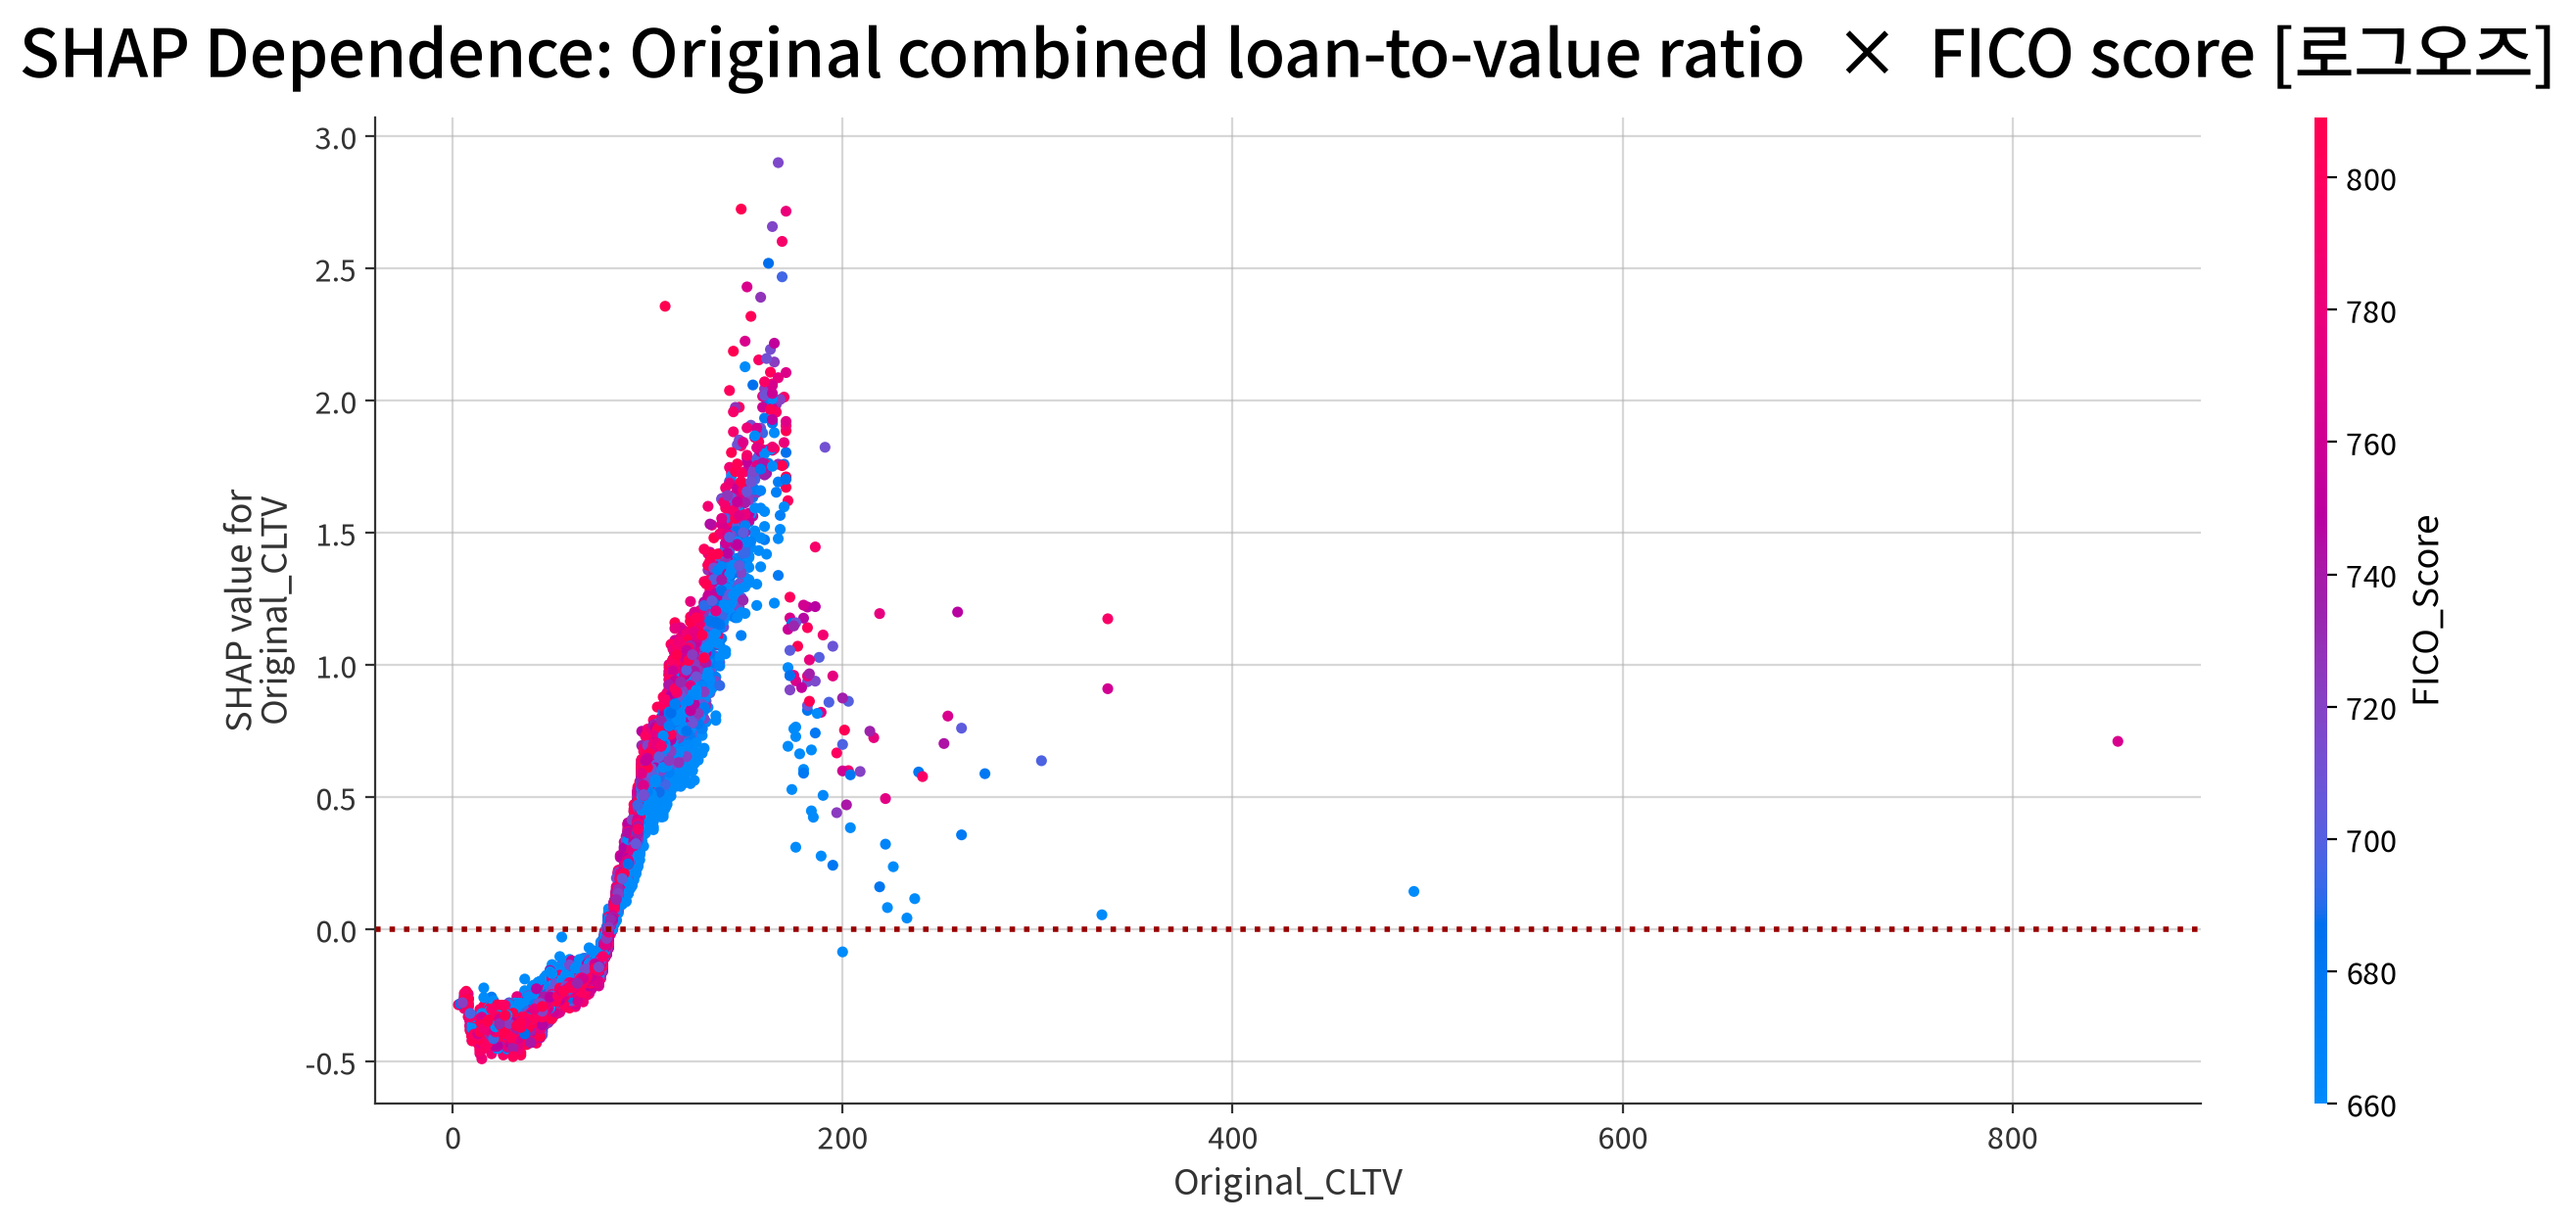

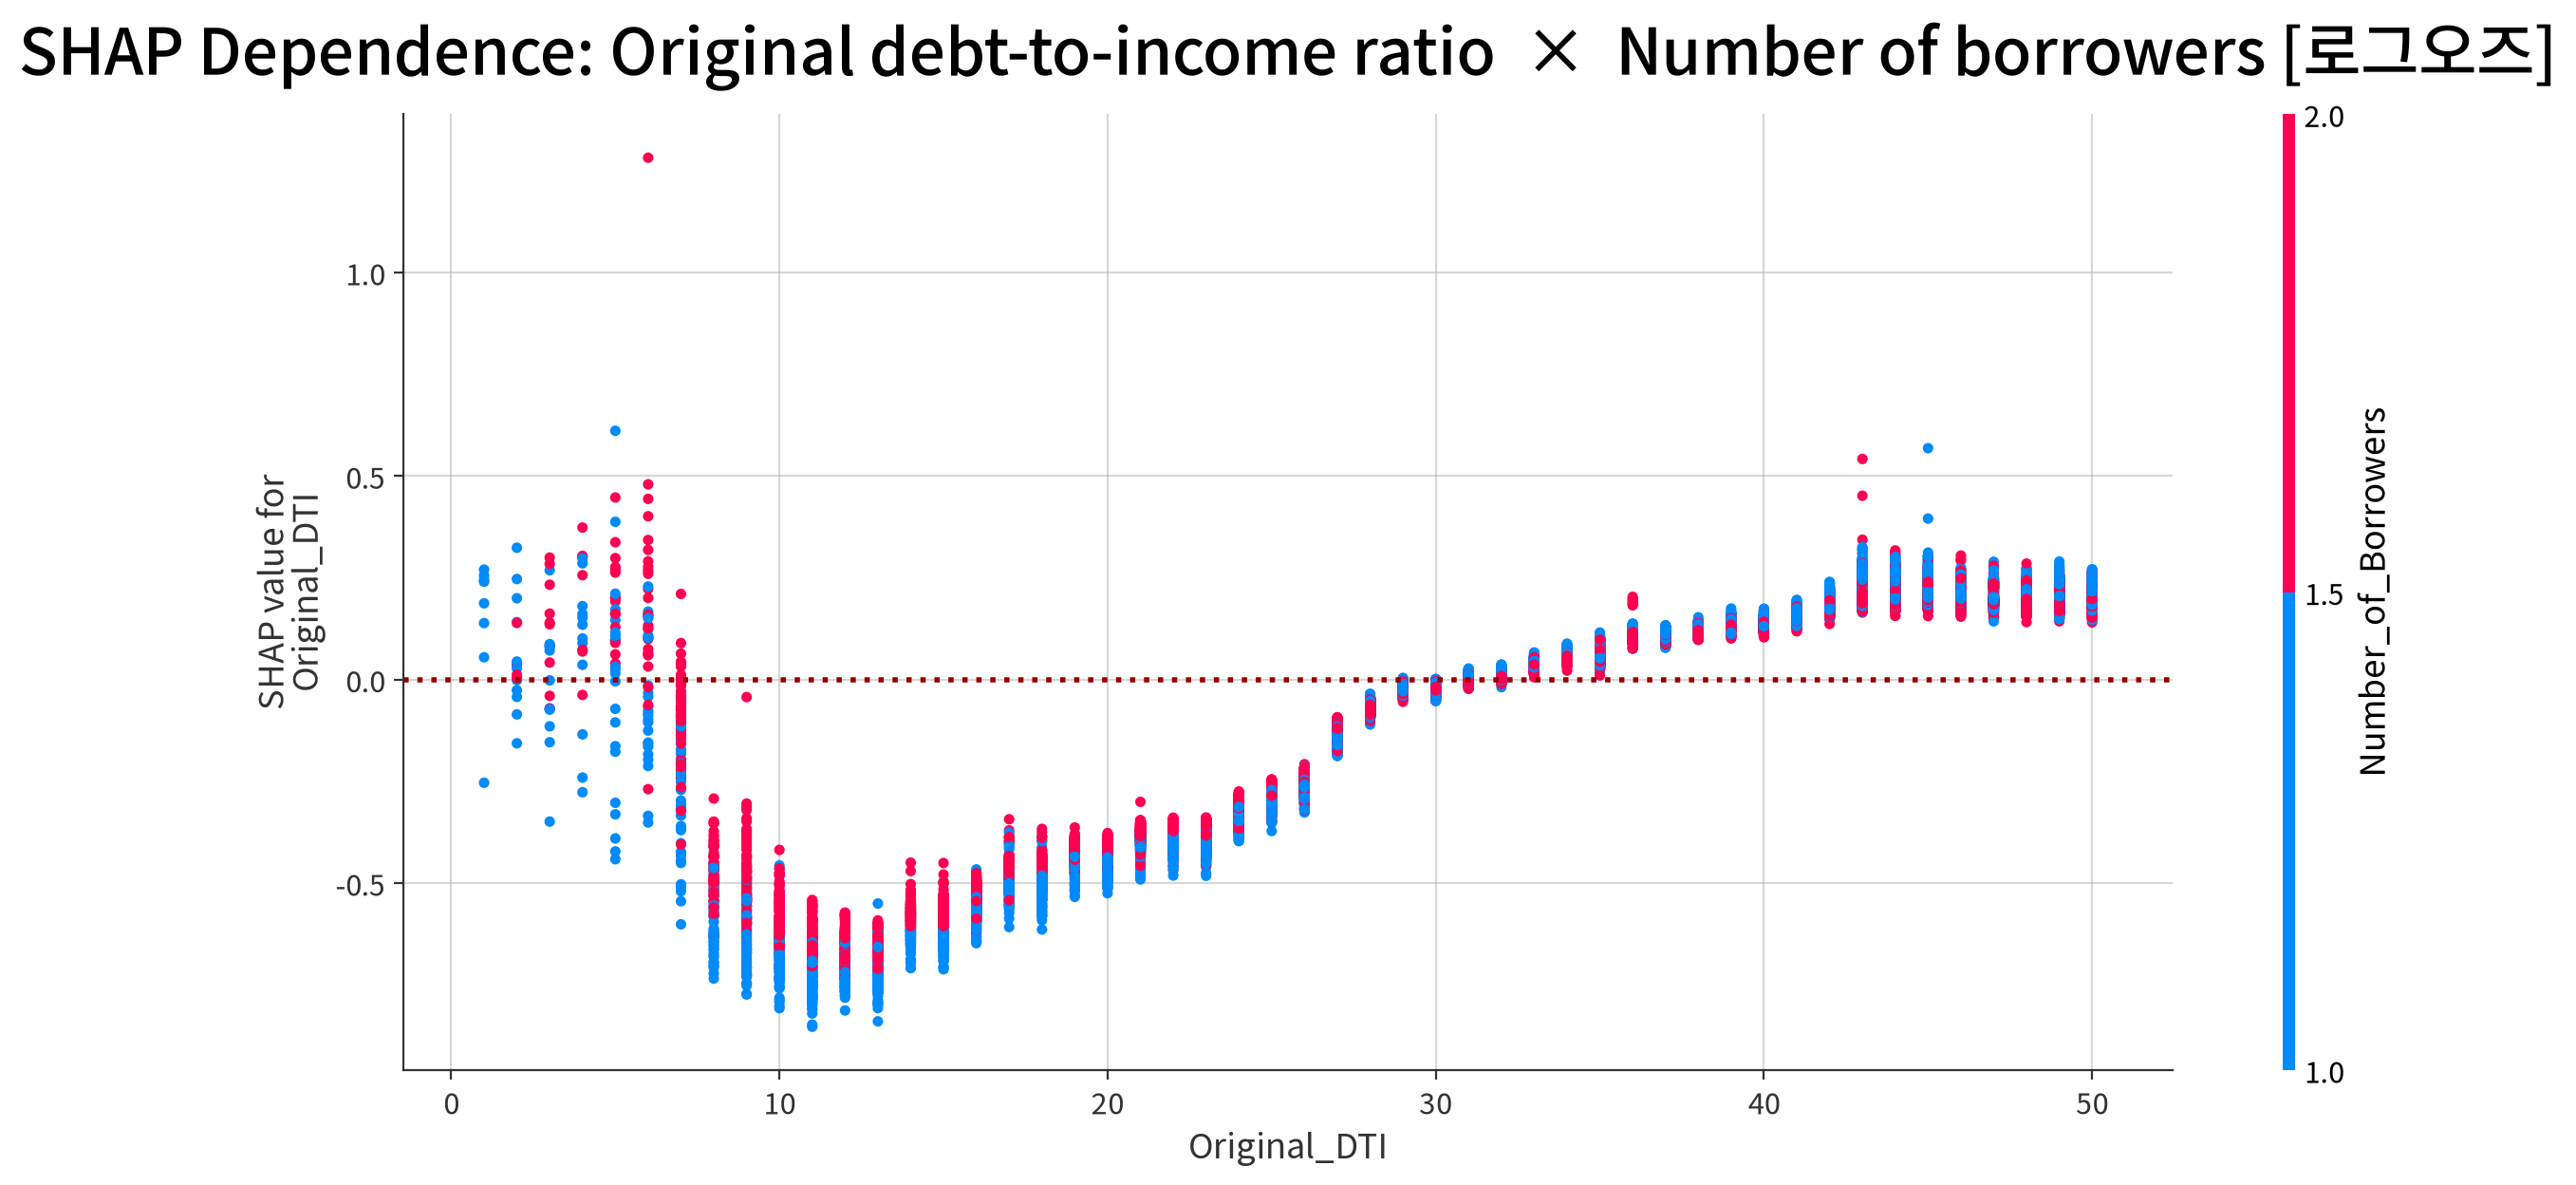

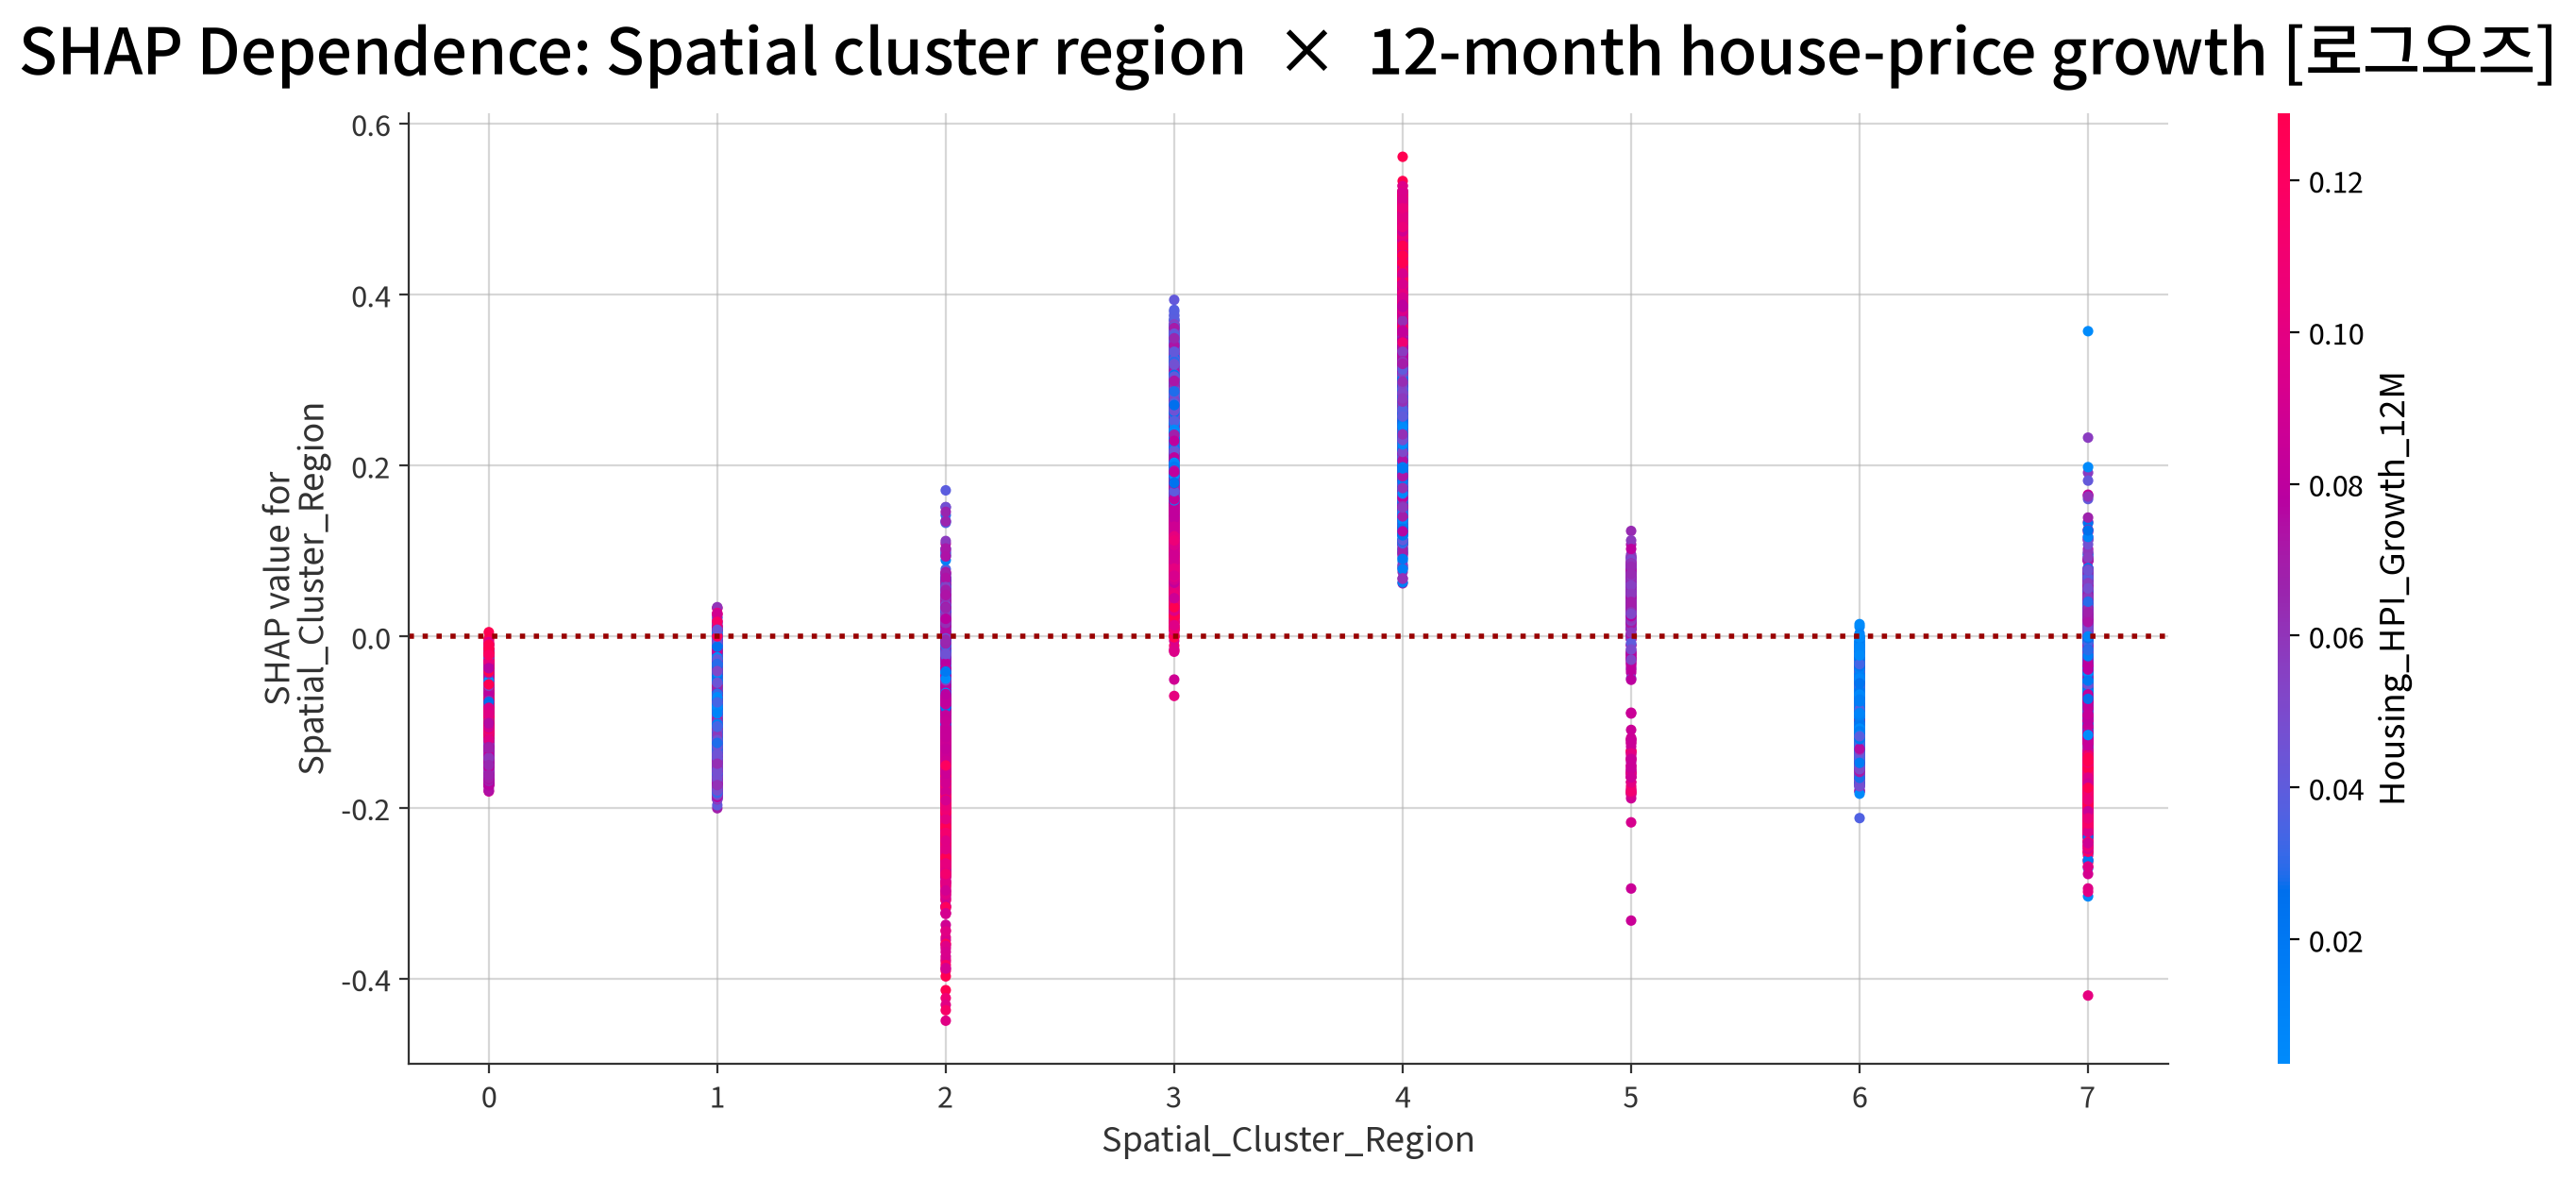

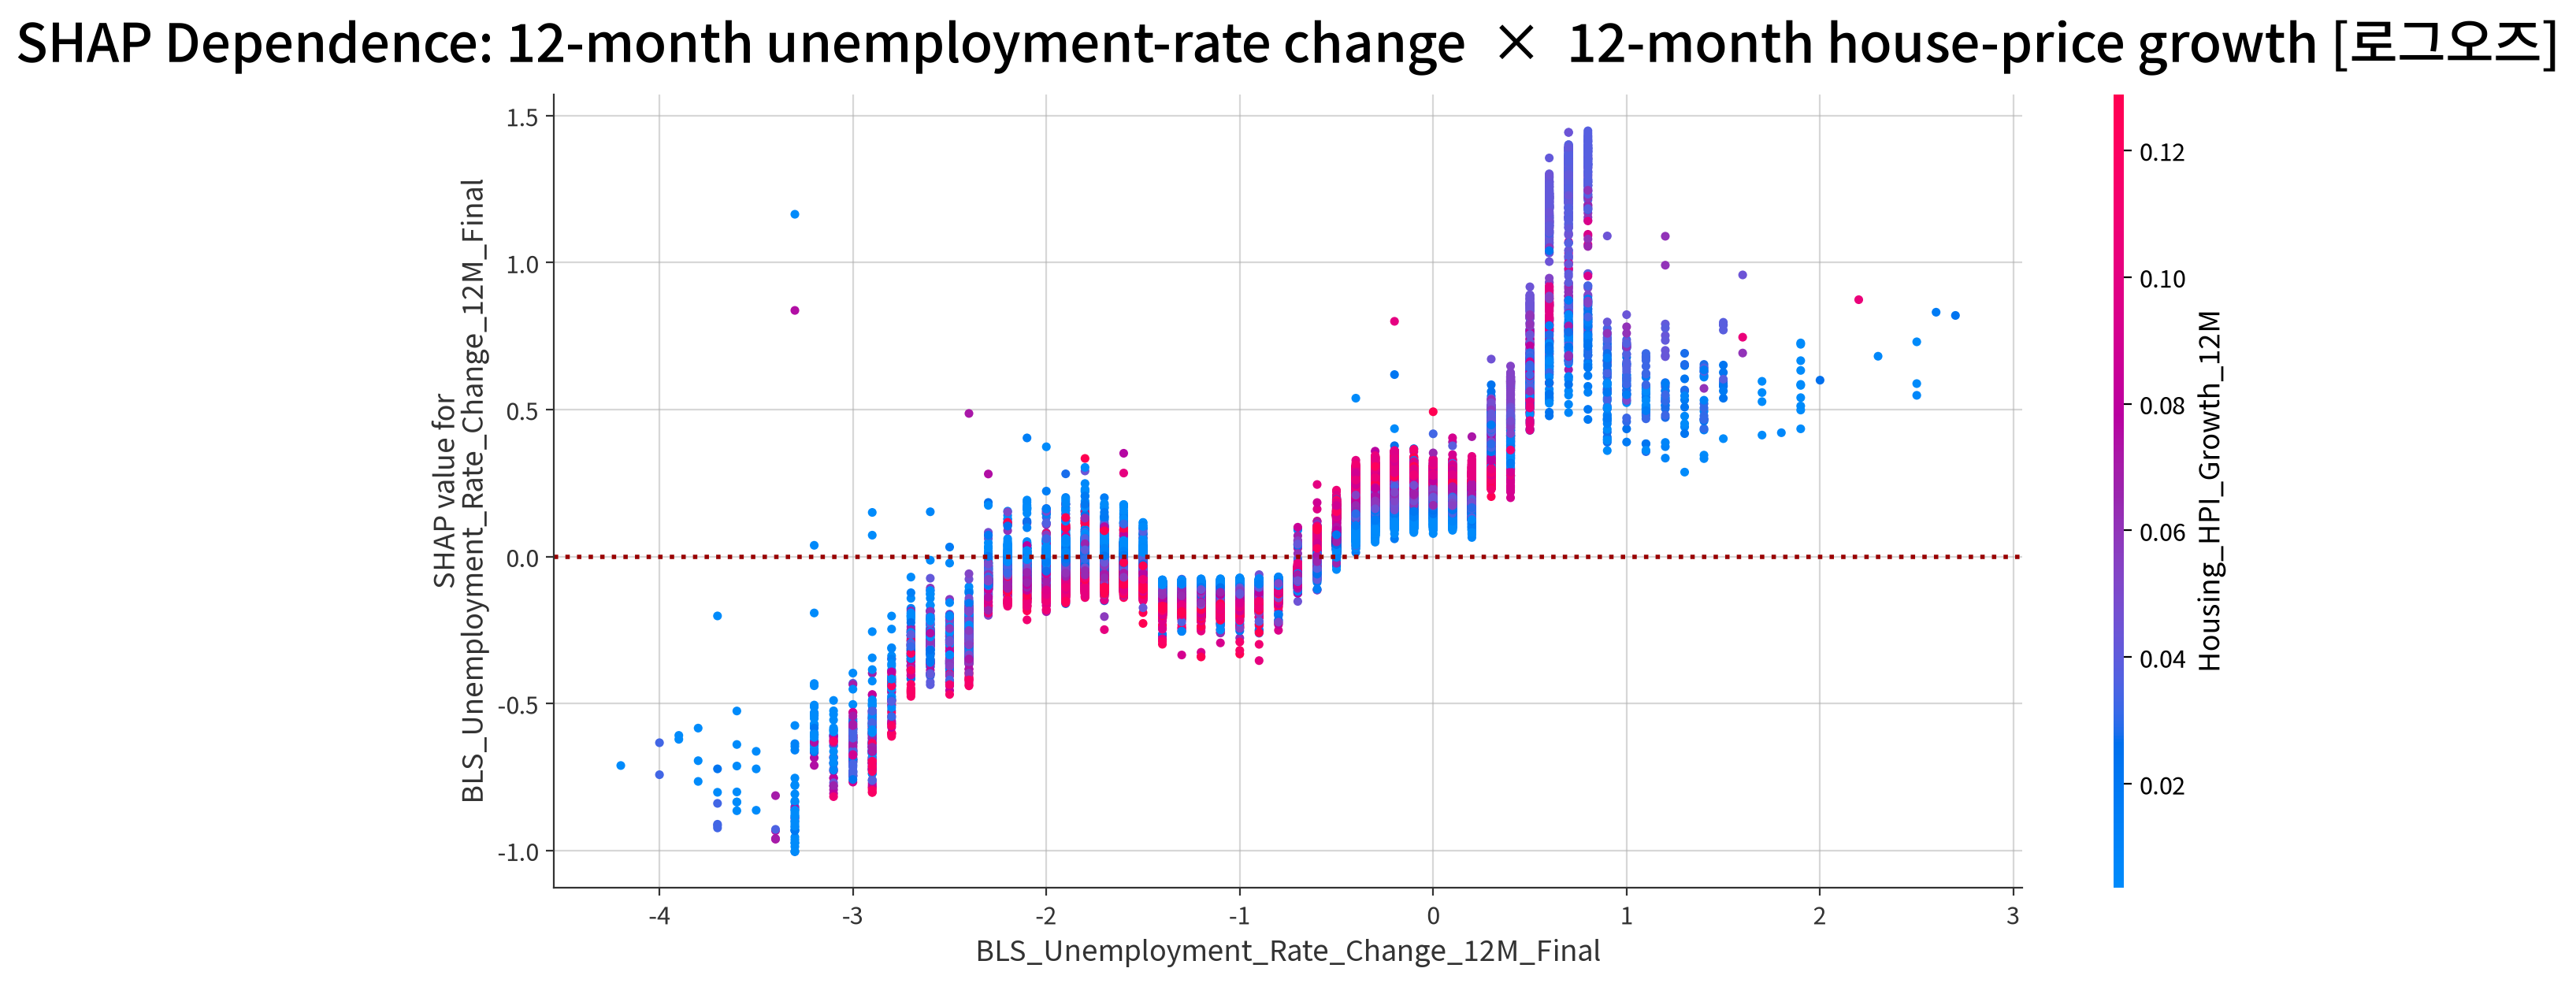

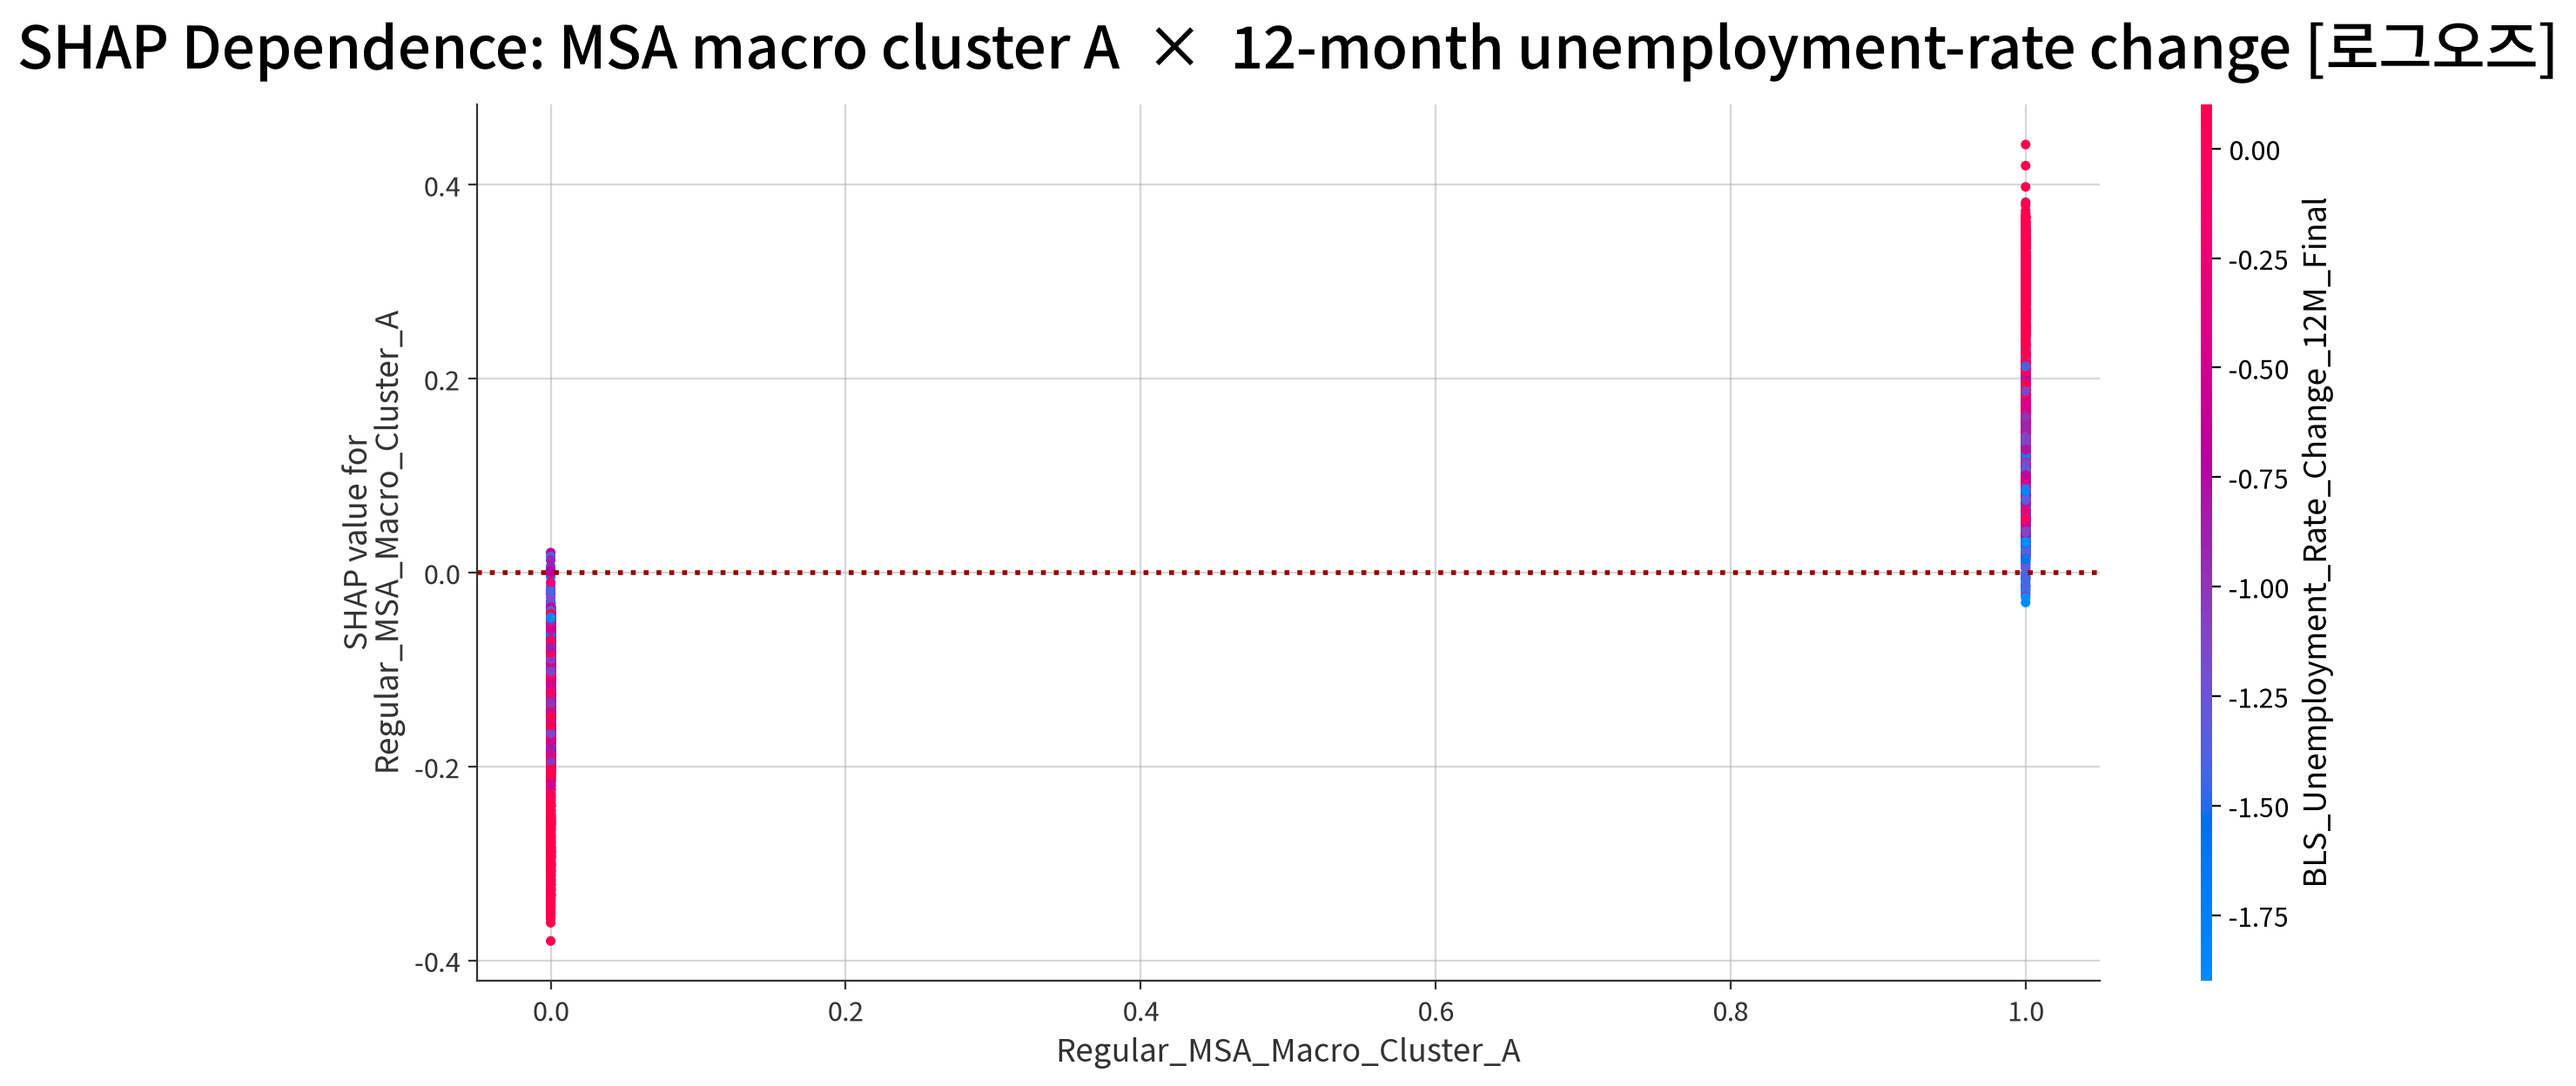

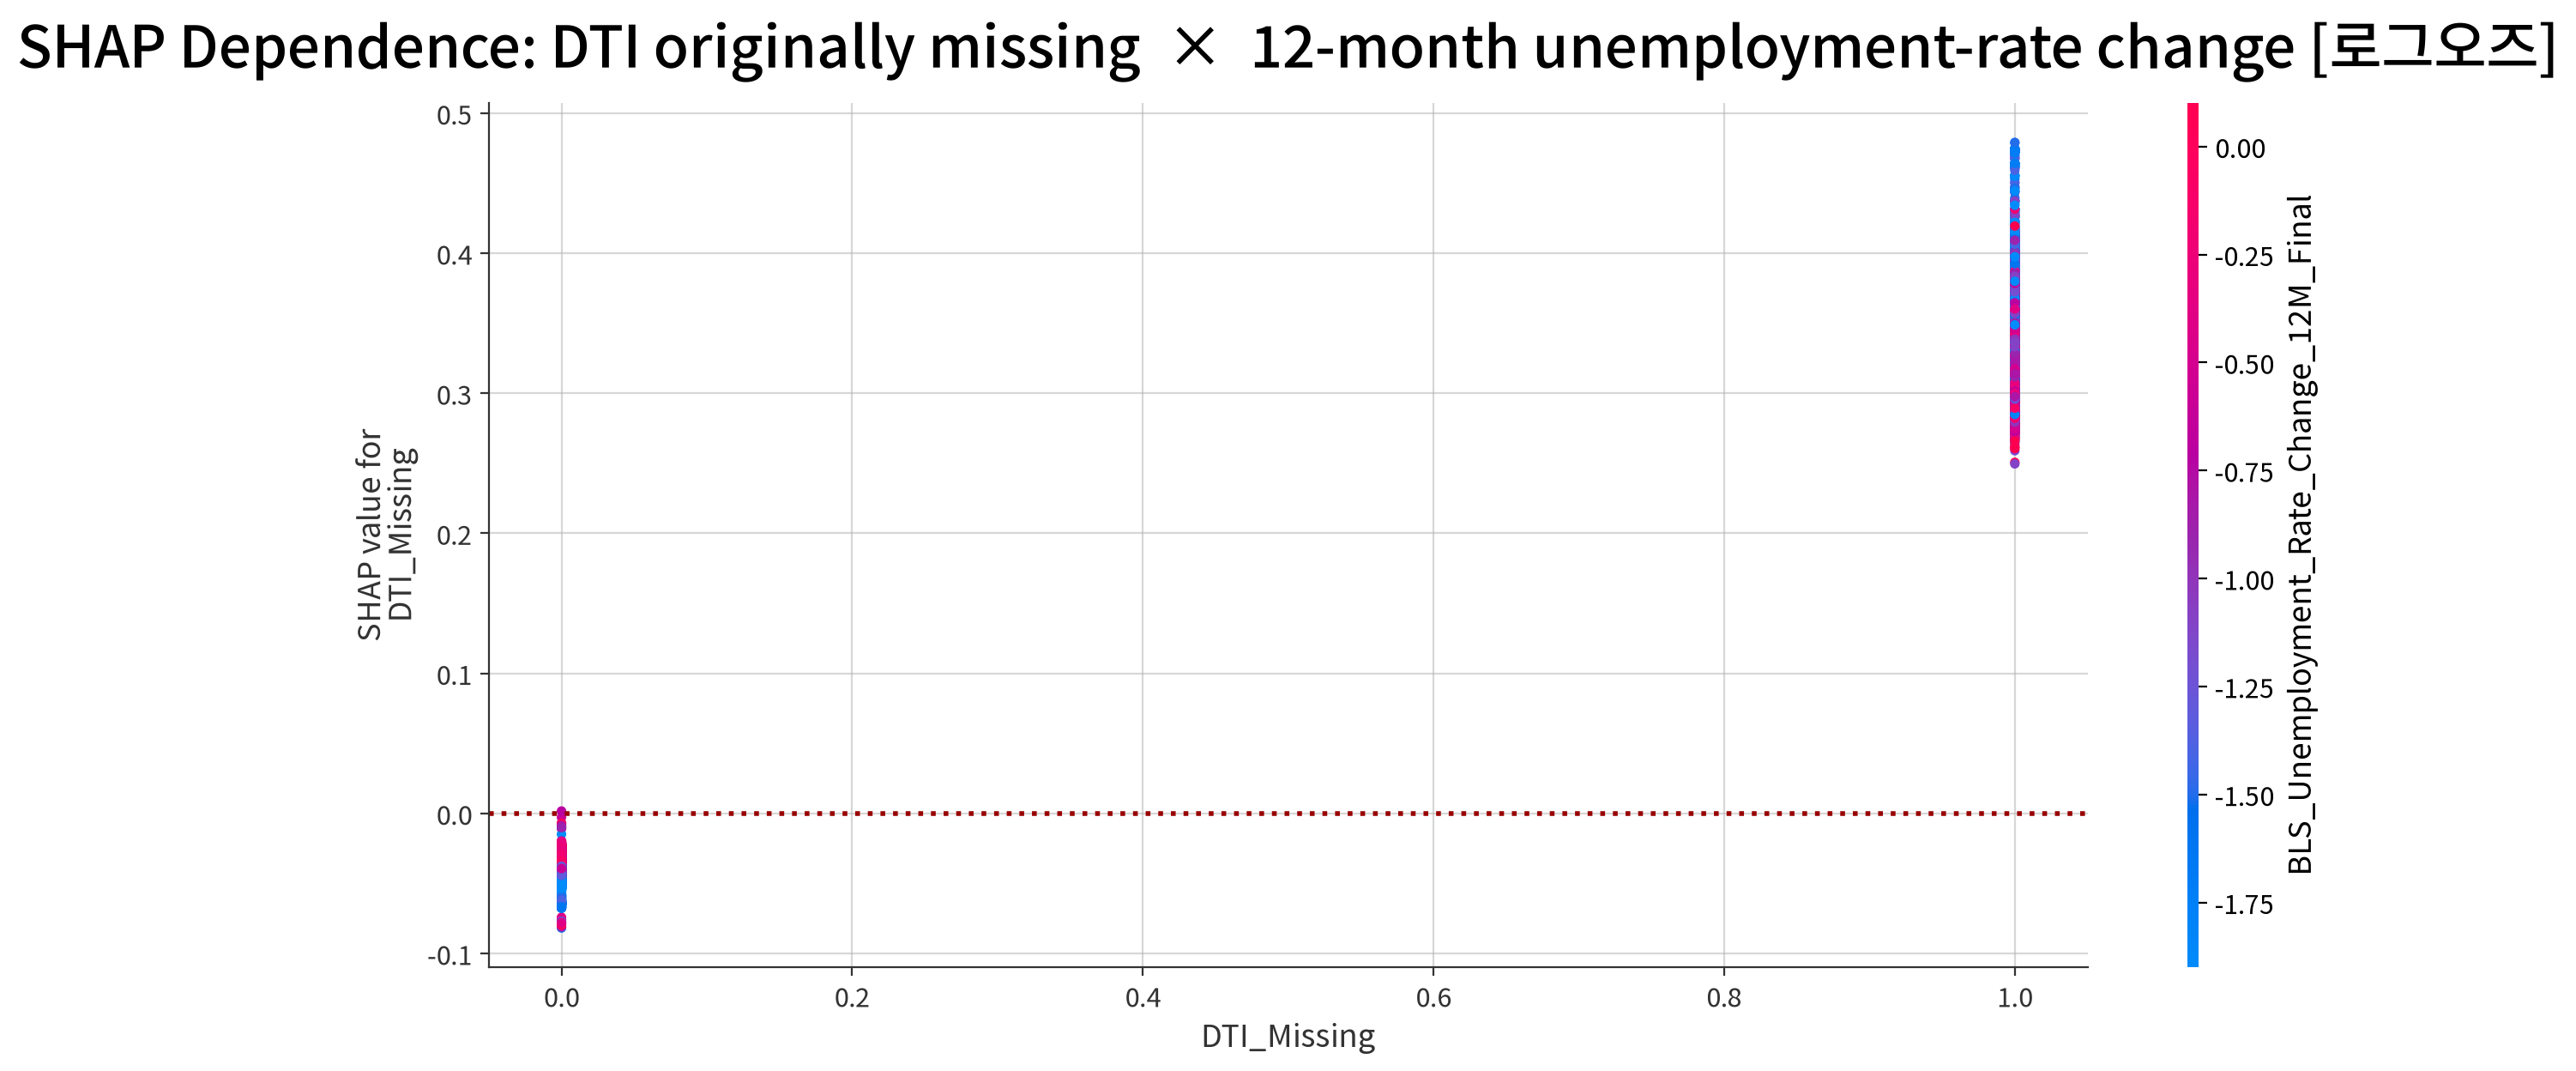

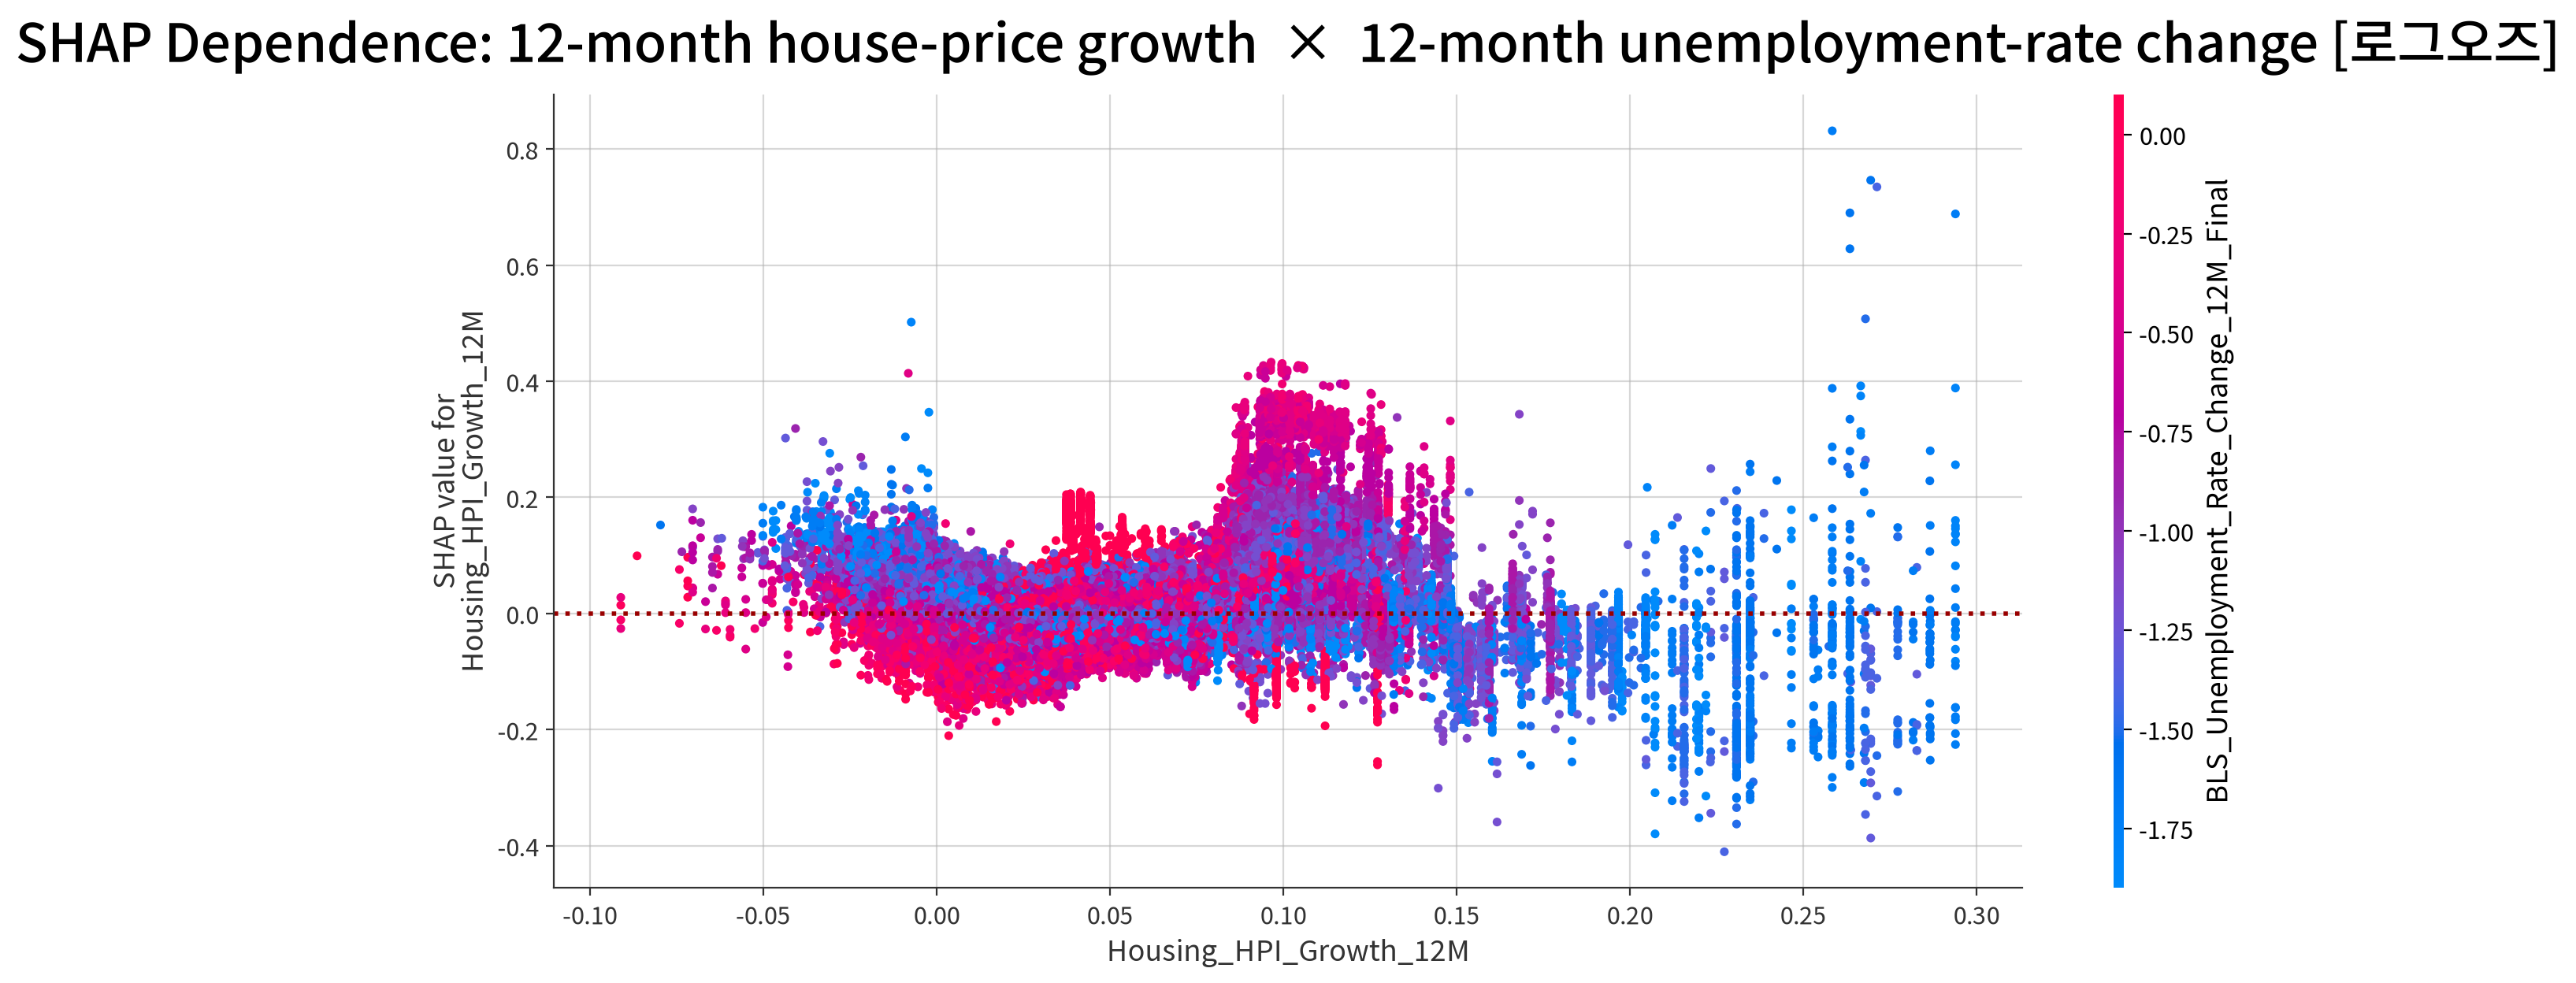

In [6]:
my_diag.shap_dependence_plot(summary, cum_ratio=cum_ratio, column_means=column_means)

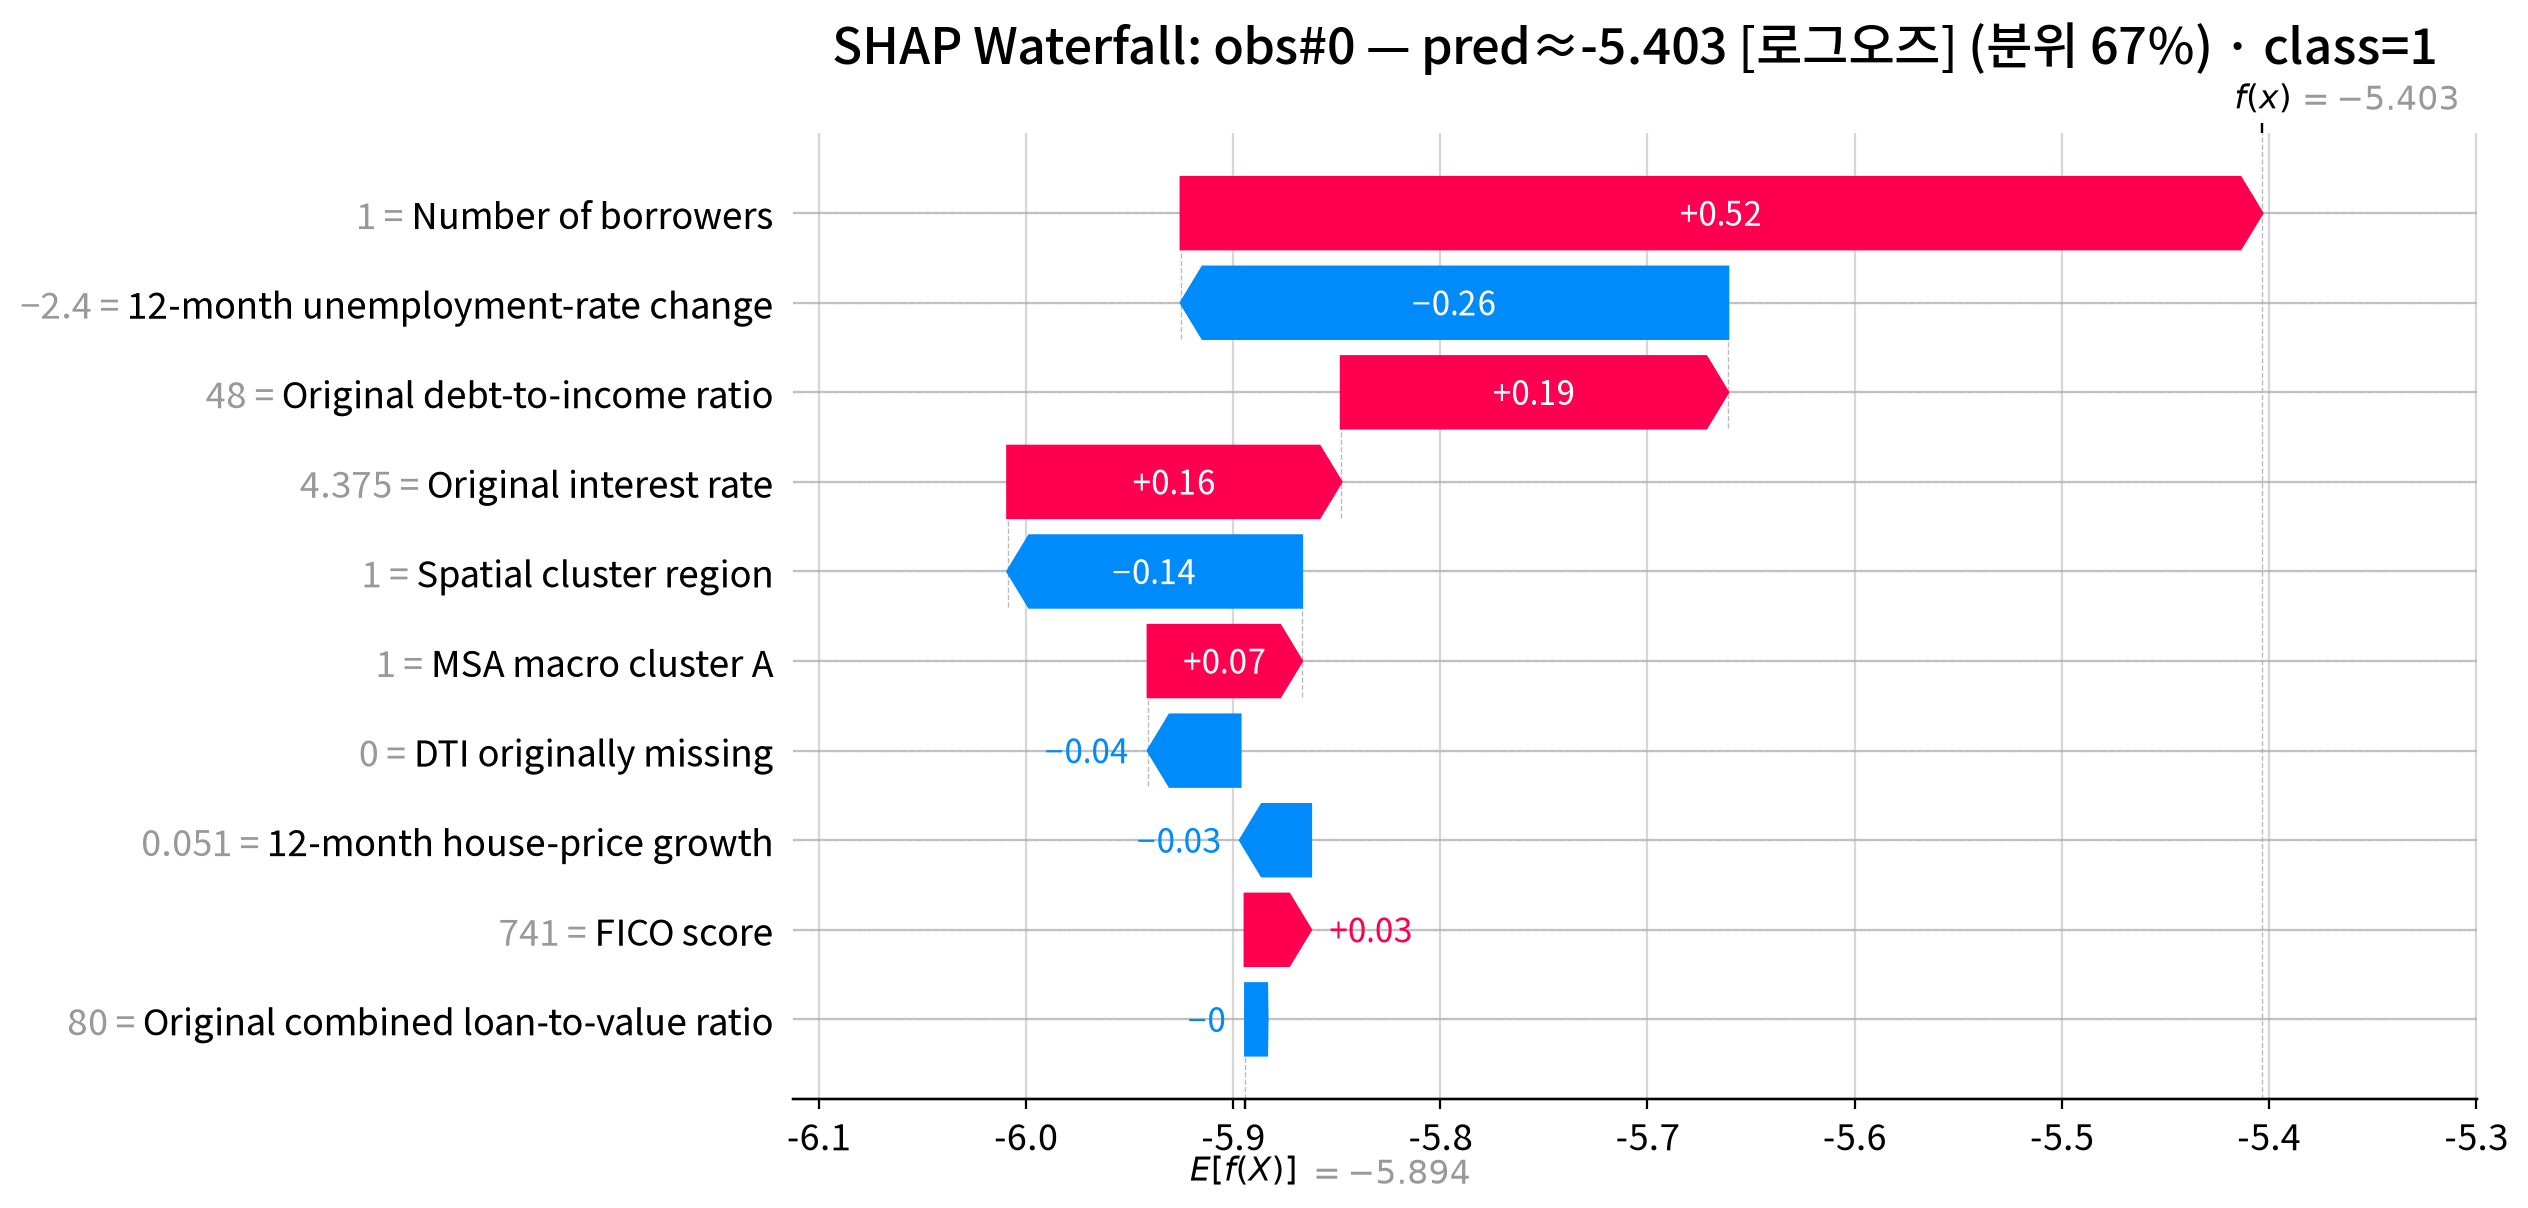

,quantile,pred,proba,FICO_Score,Original_DTI,Original_CLTV,Original_Interest_Rate,Number_of_Borrowers,Housing_HPI_Growth_12M,BLS_Unemployment_Rate_Change_12M_Final,DTI_Missing,Spatial_Cluster_Region,Regular_MSA_Macro_Cluster_A
47556,0.665042,-5.403282,0.004482,741.0,48.0,80.0,4.375,1,0.050741,-2.4,0,1,1


In [7]:
# The first row is available even if shap_analysis internally samples rows.
my_diag.shap_waterfall_plot(
    summary, index=0, cum_ratio=cum_ratio,
    column_means=column_means,
)


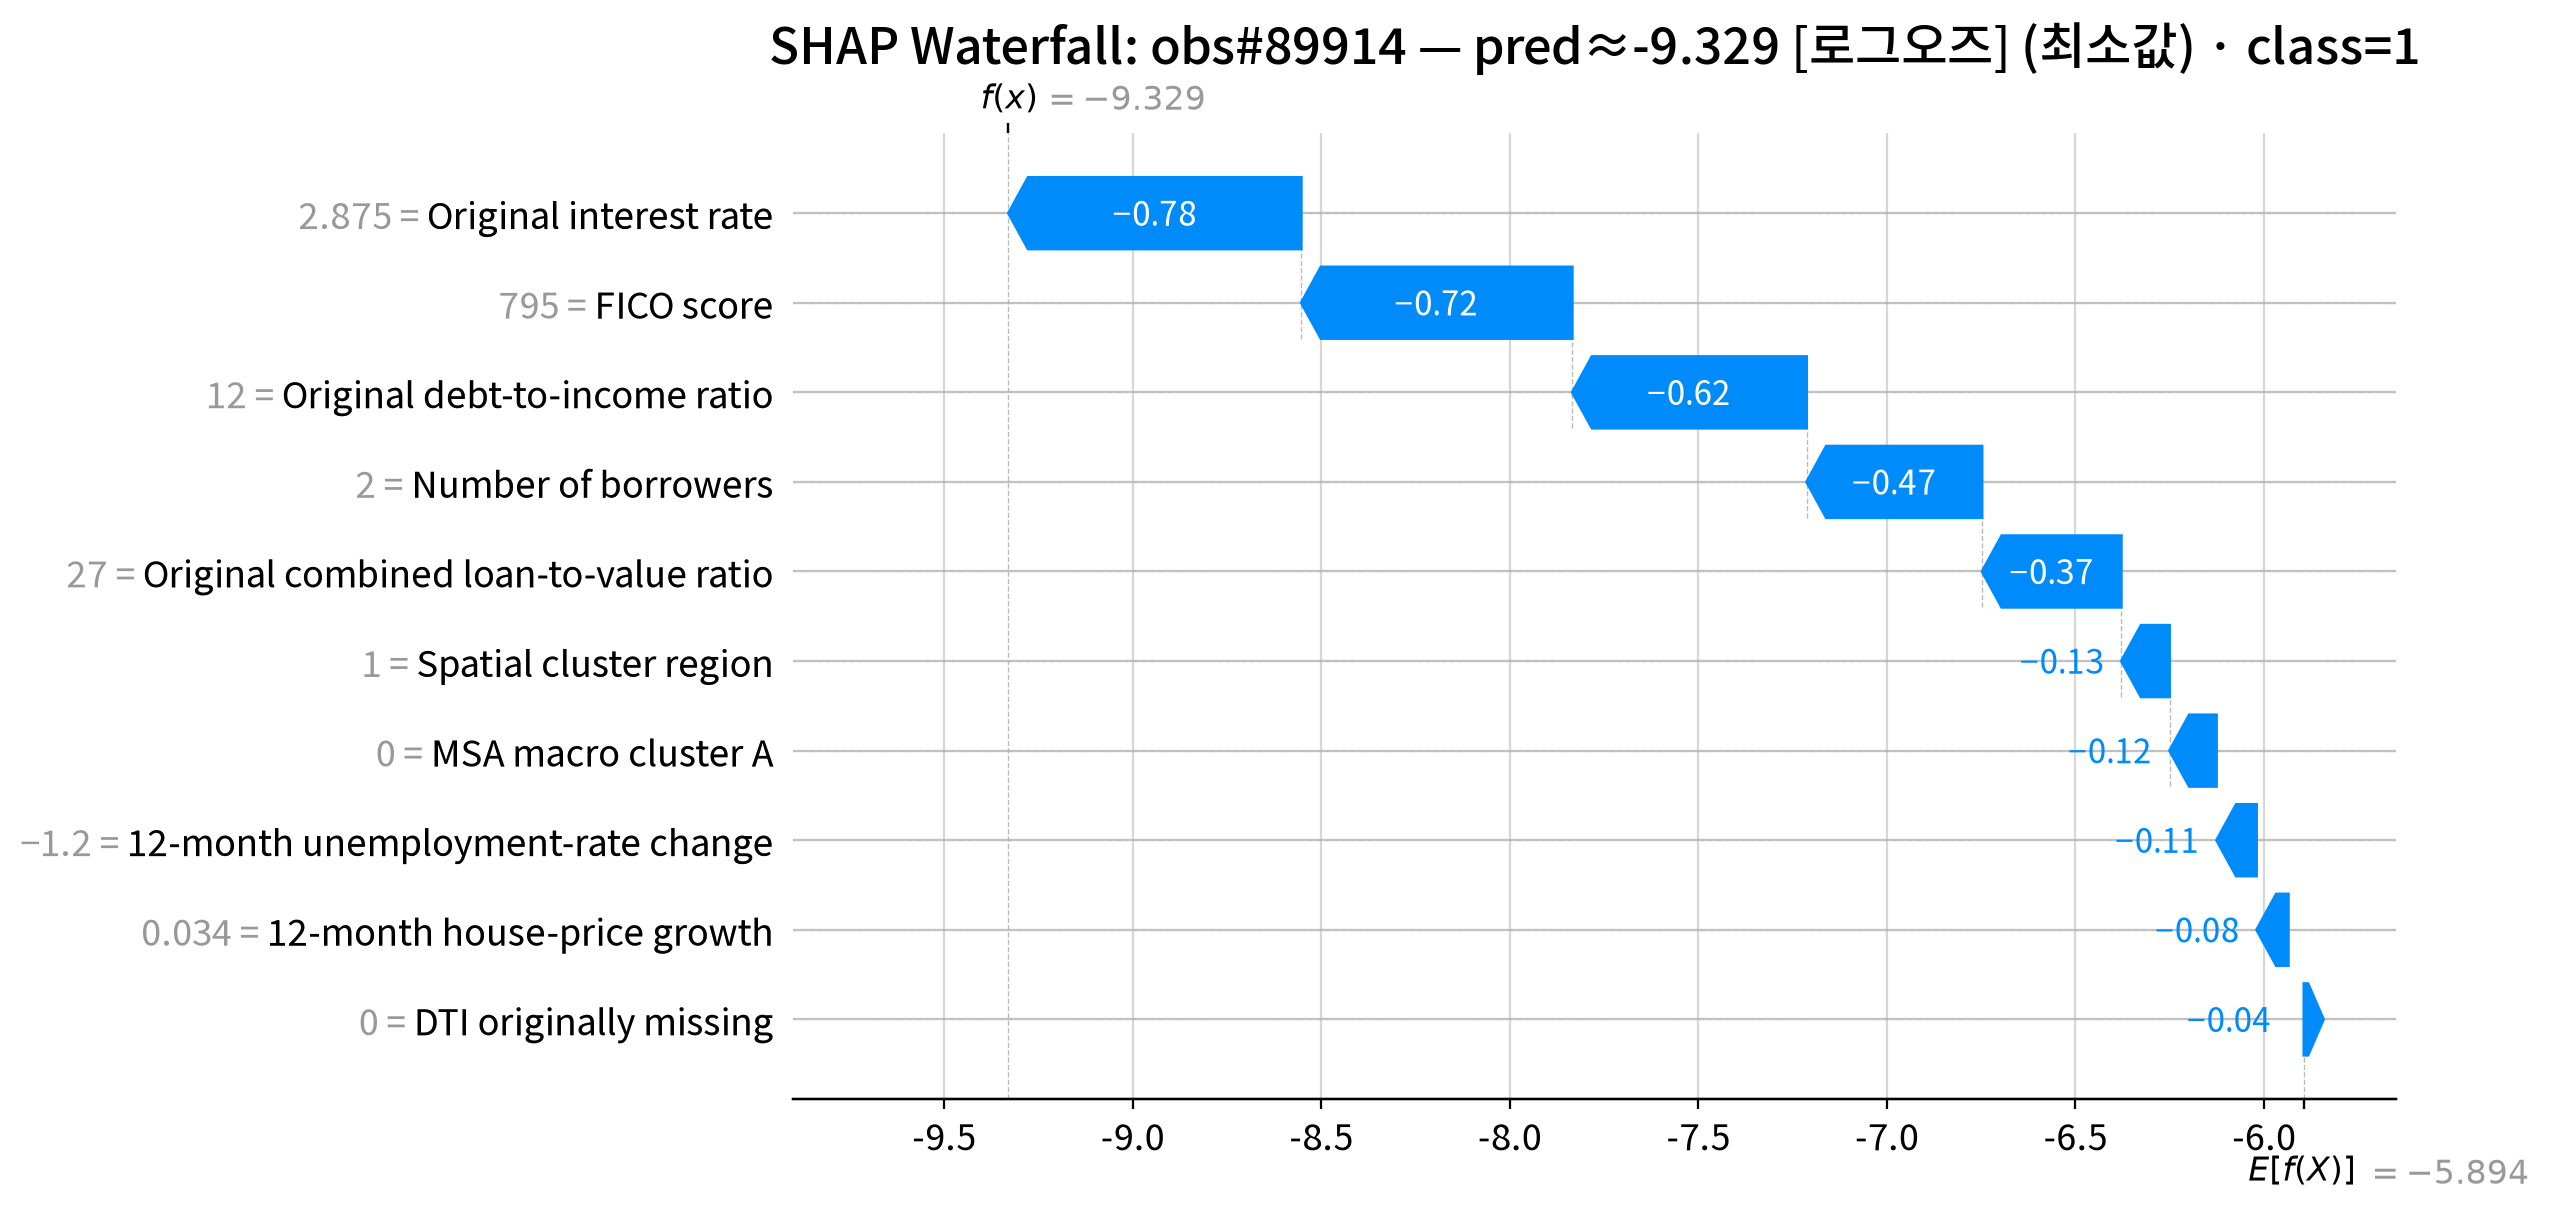

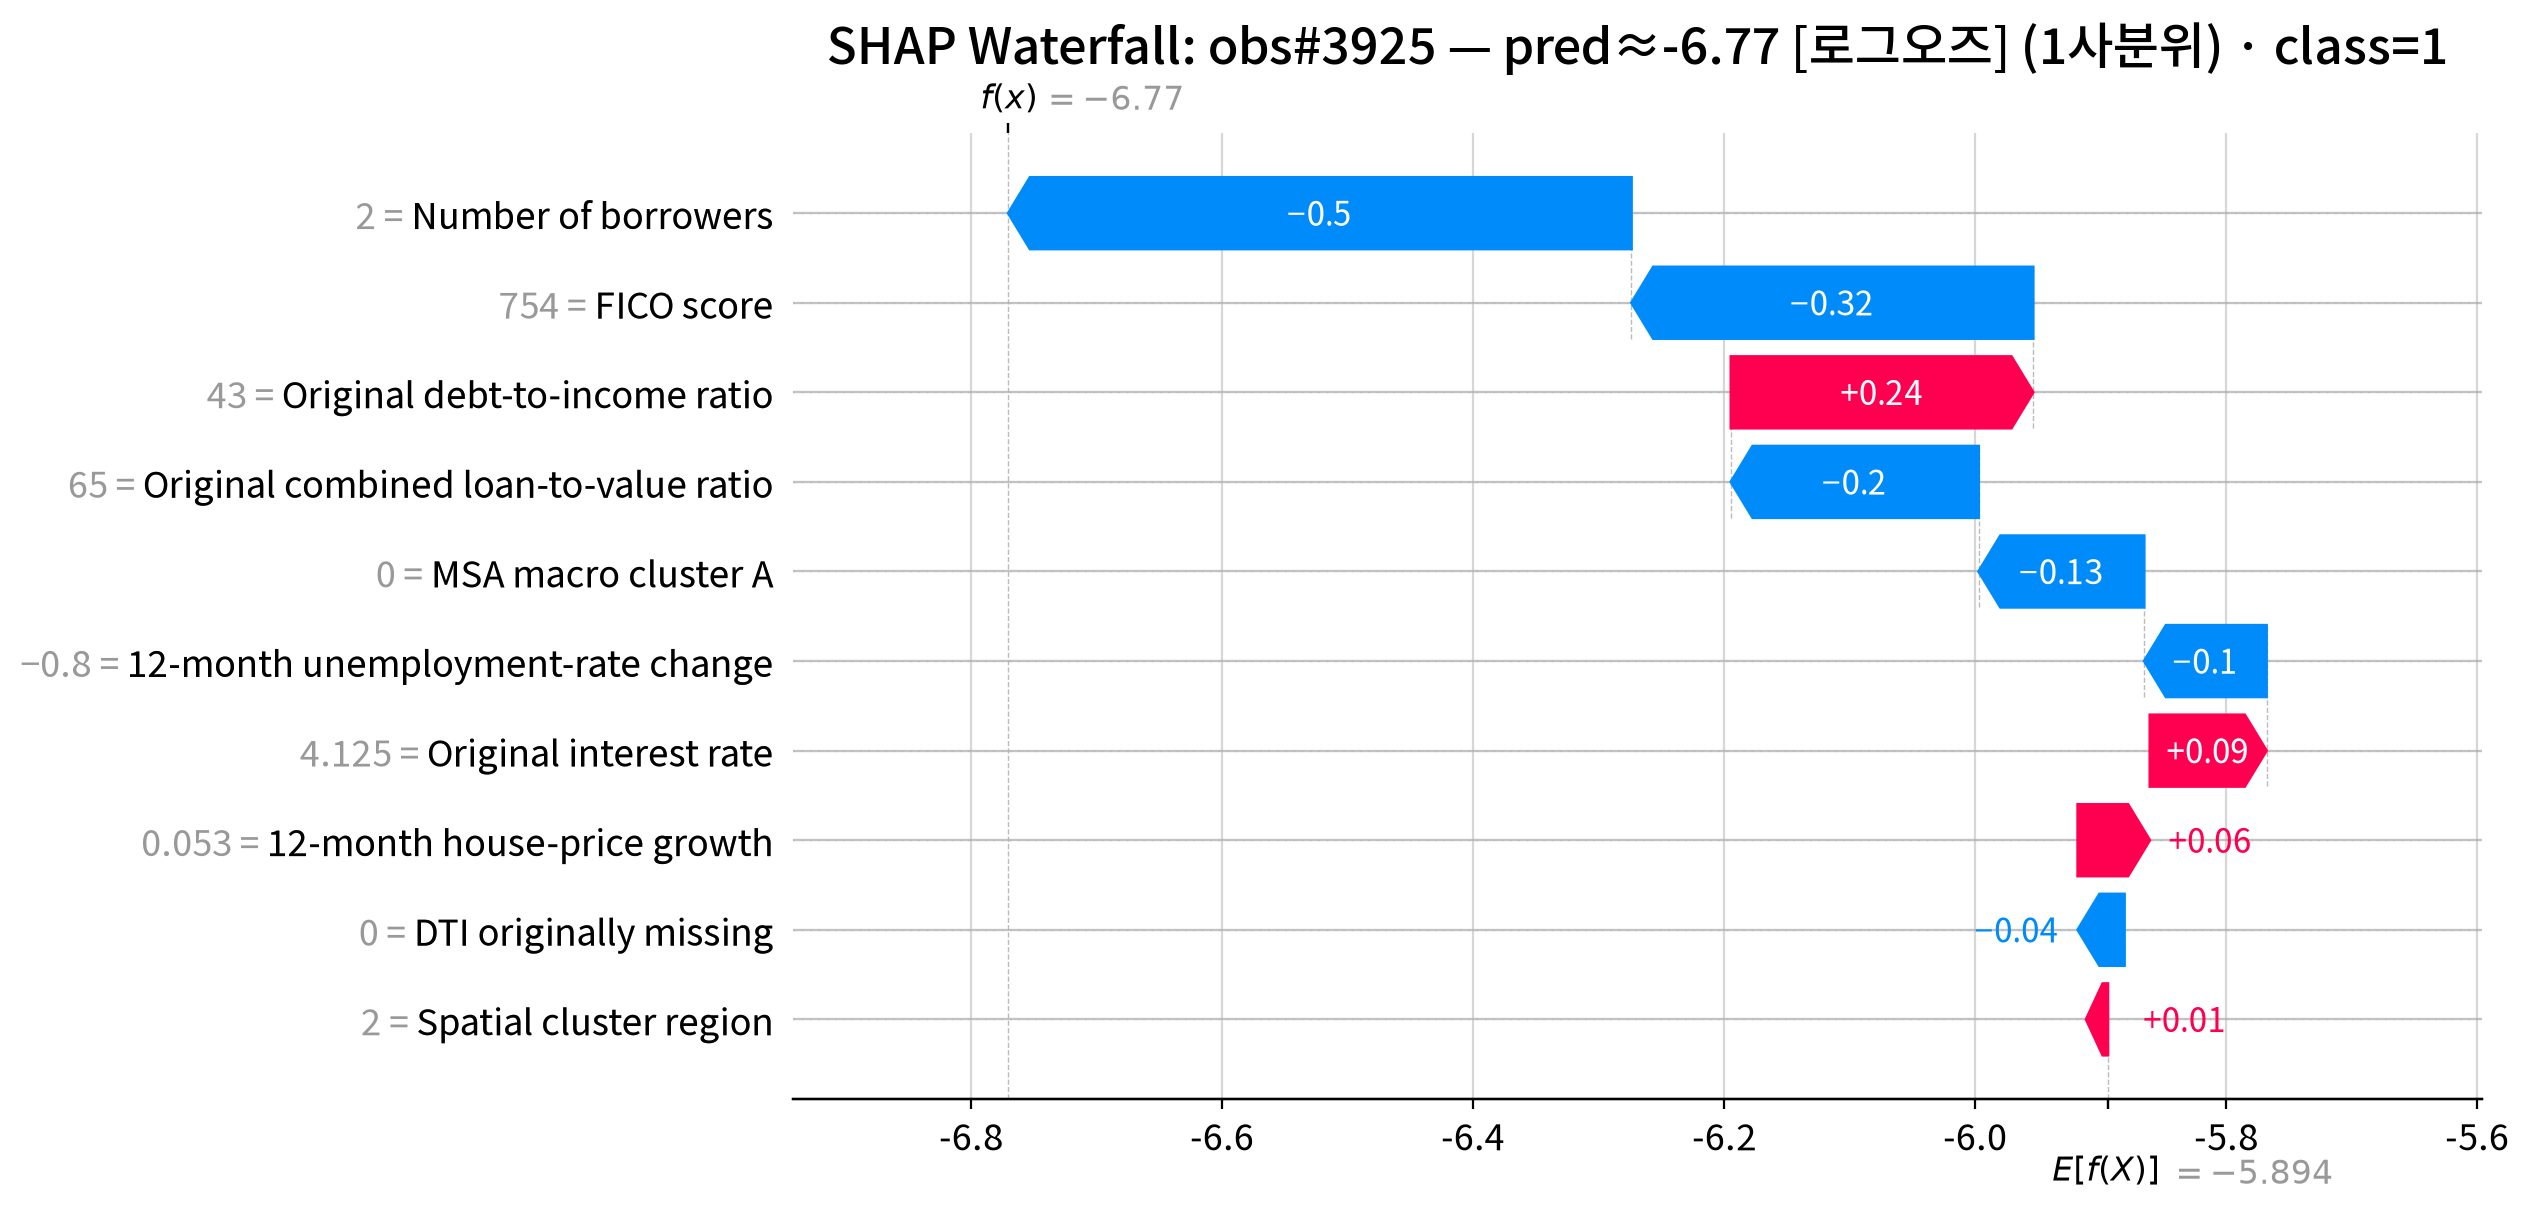

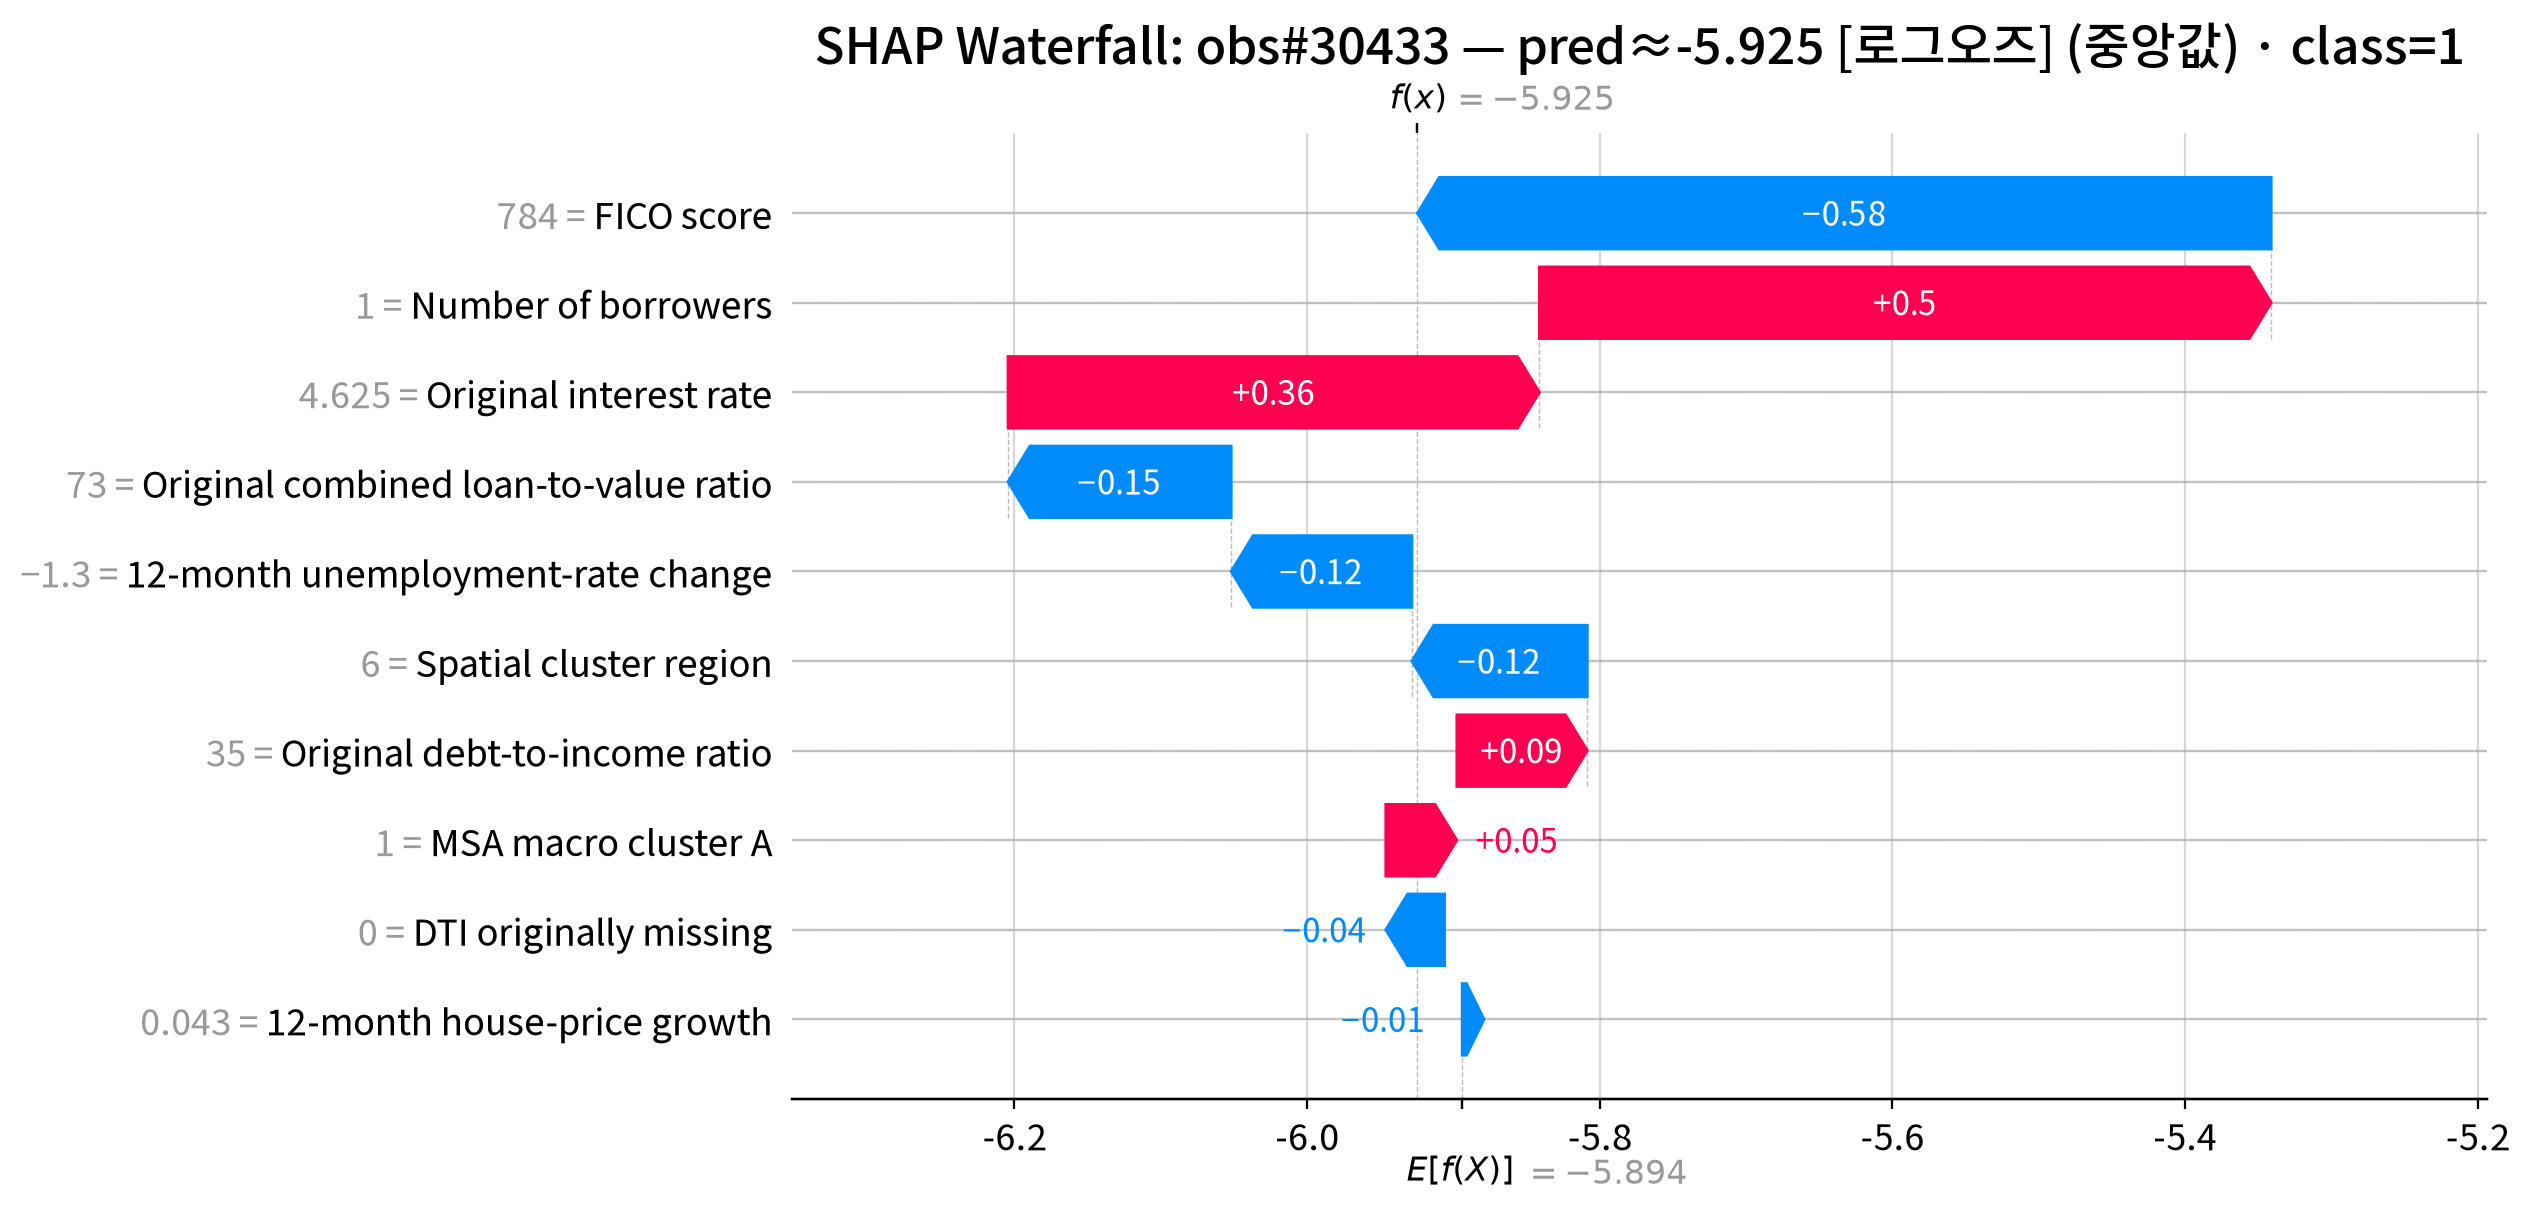

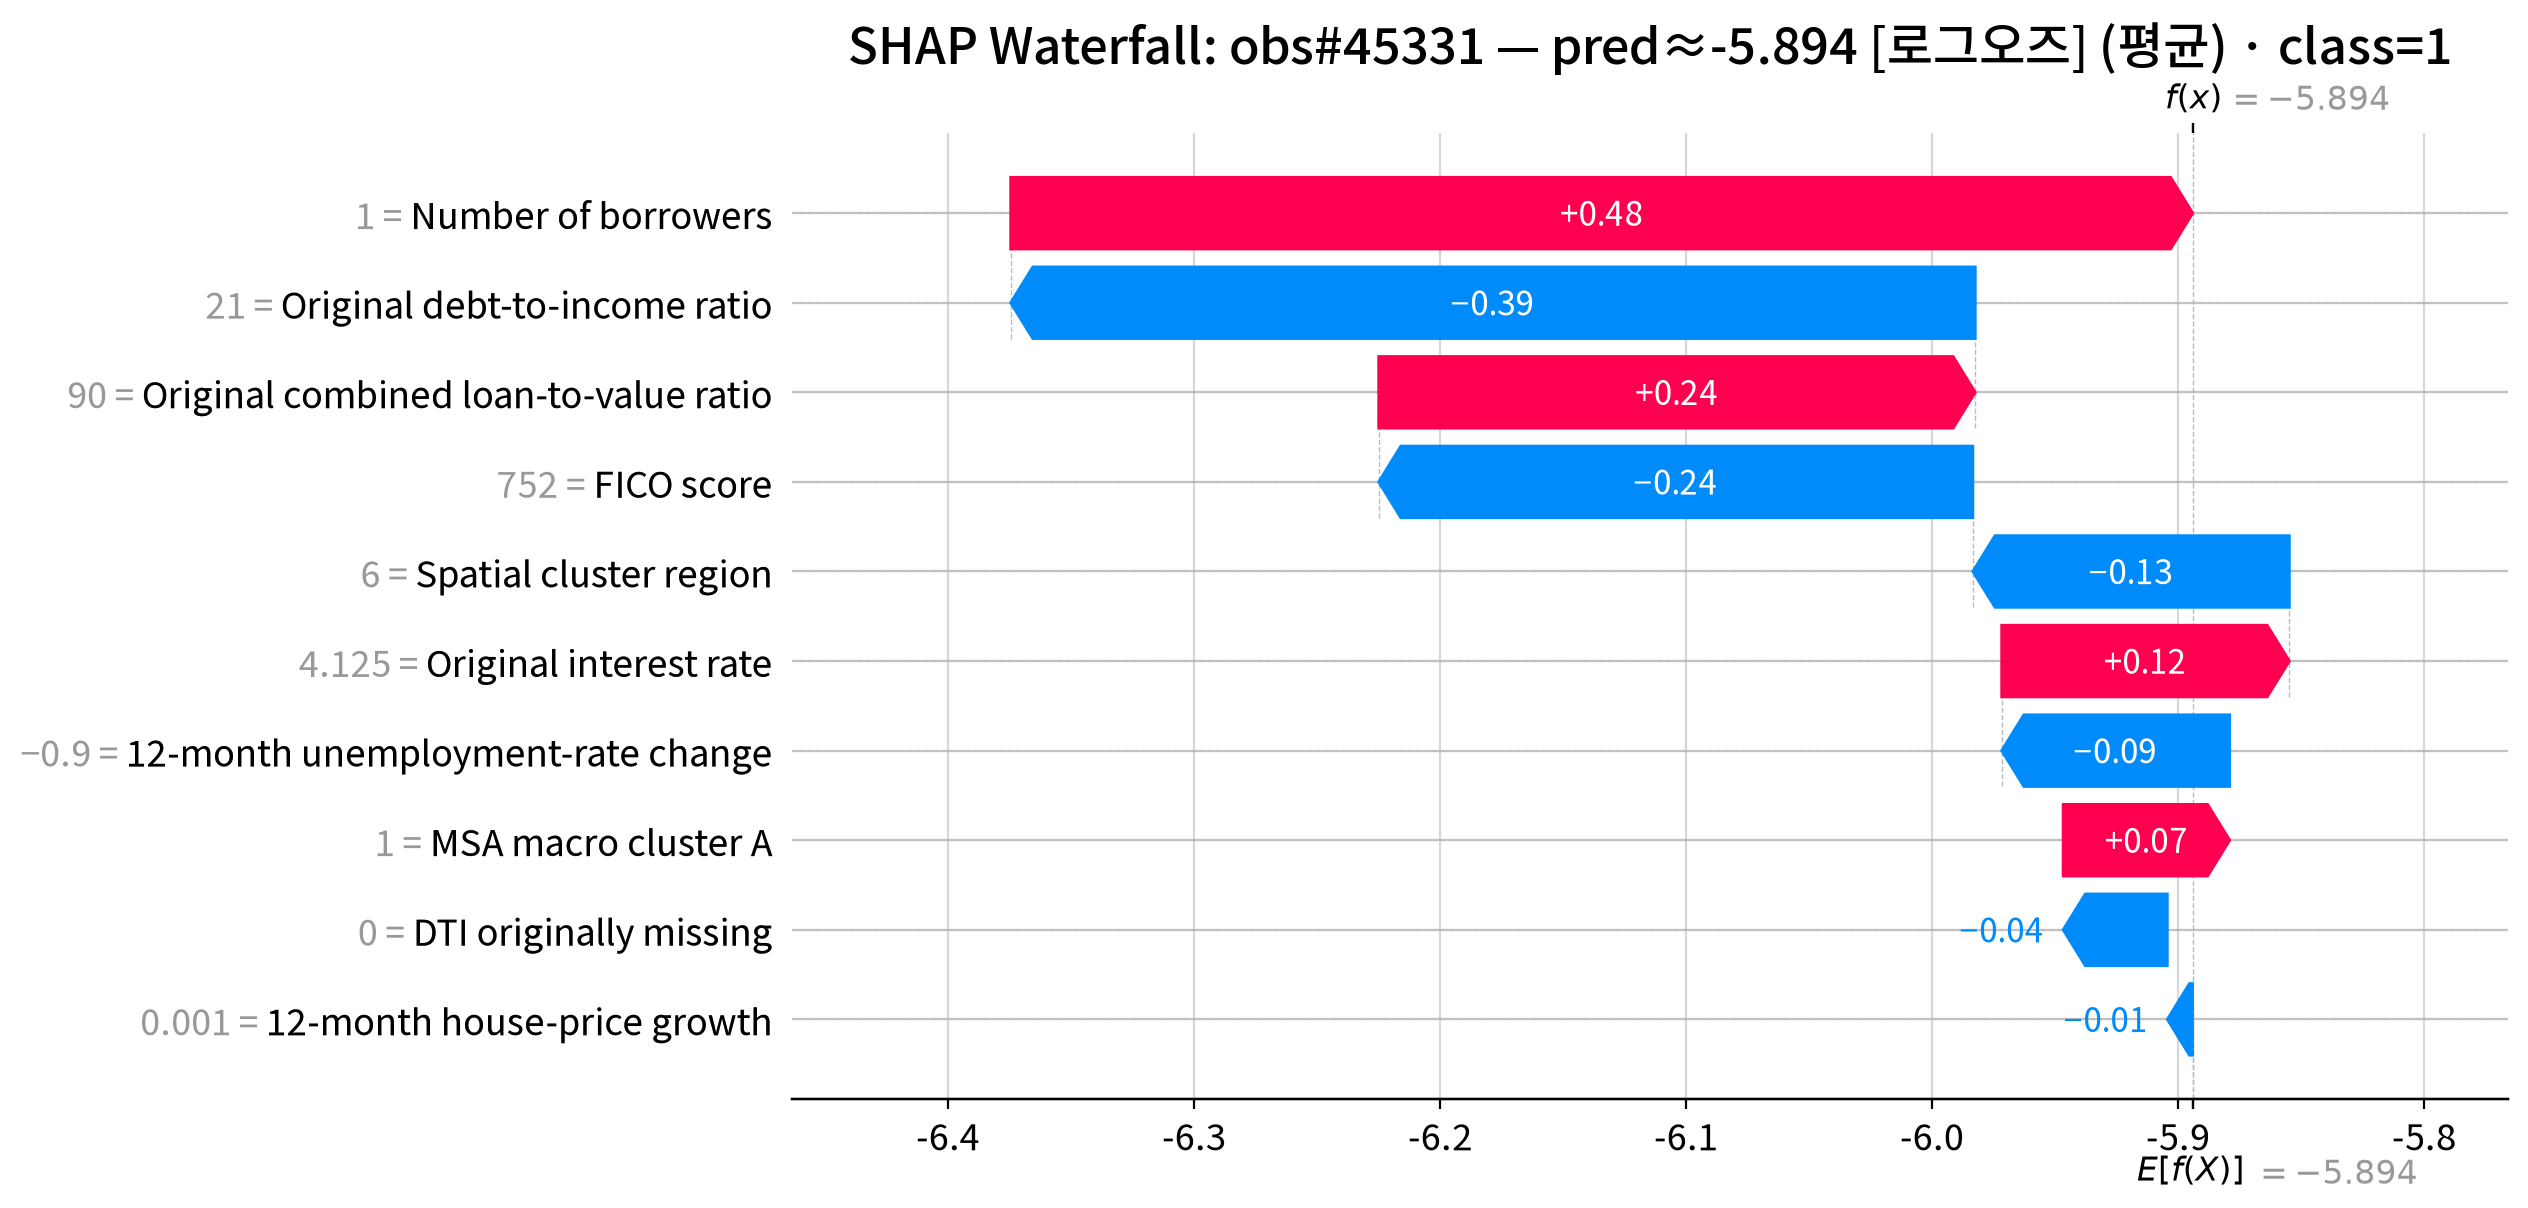

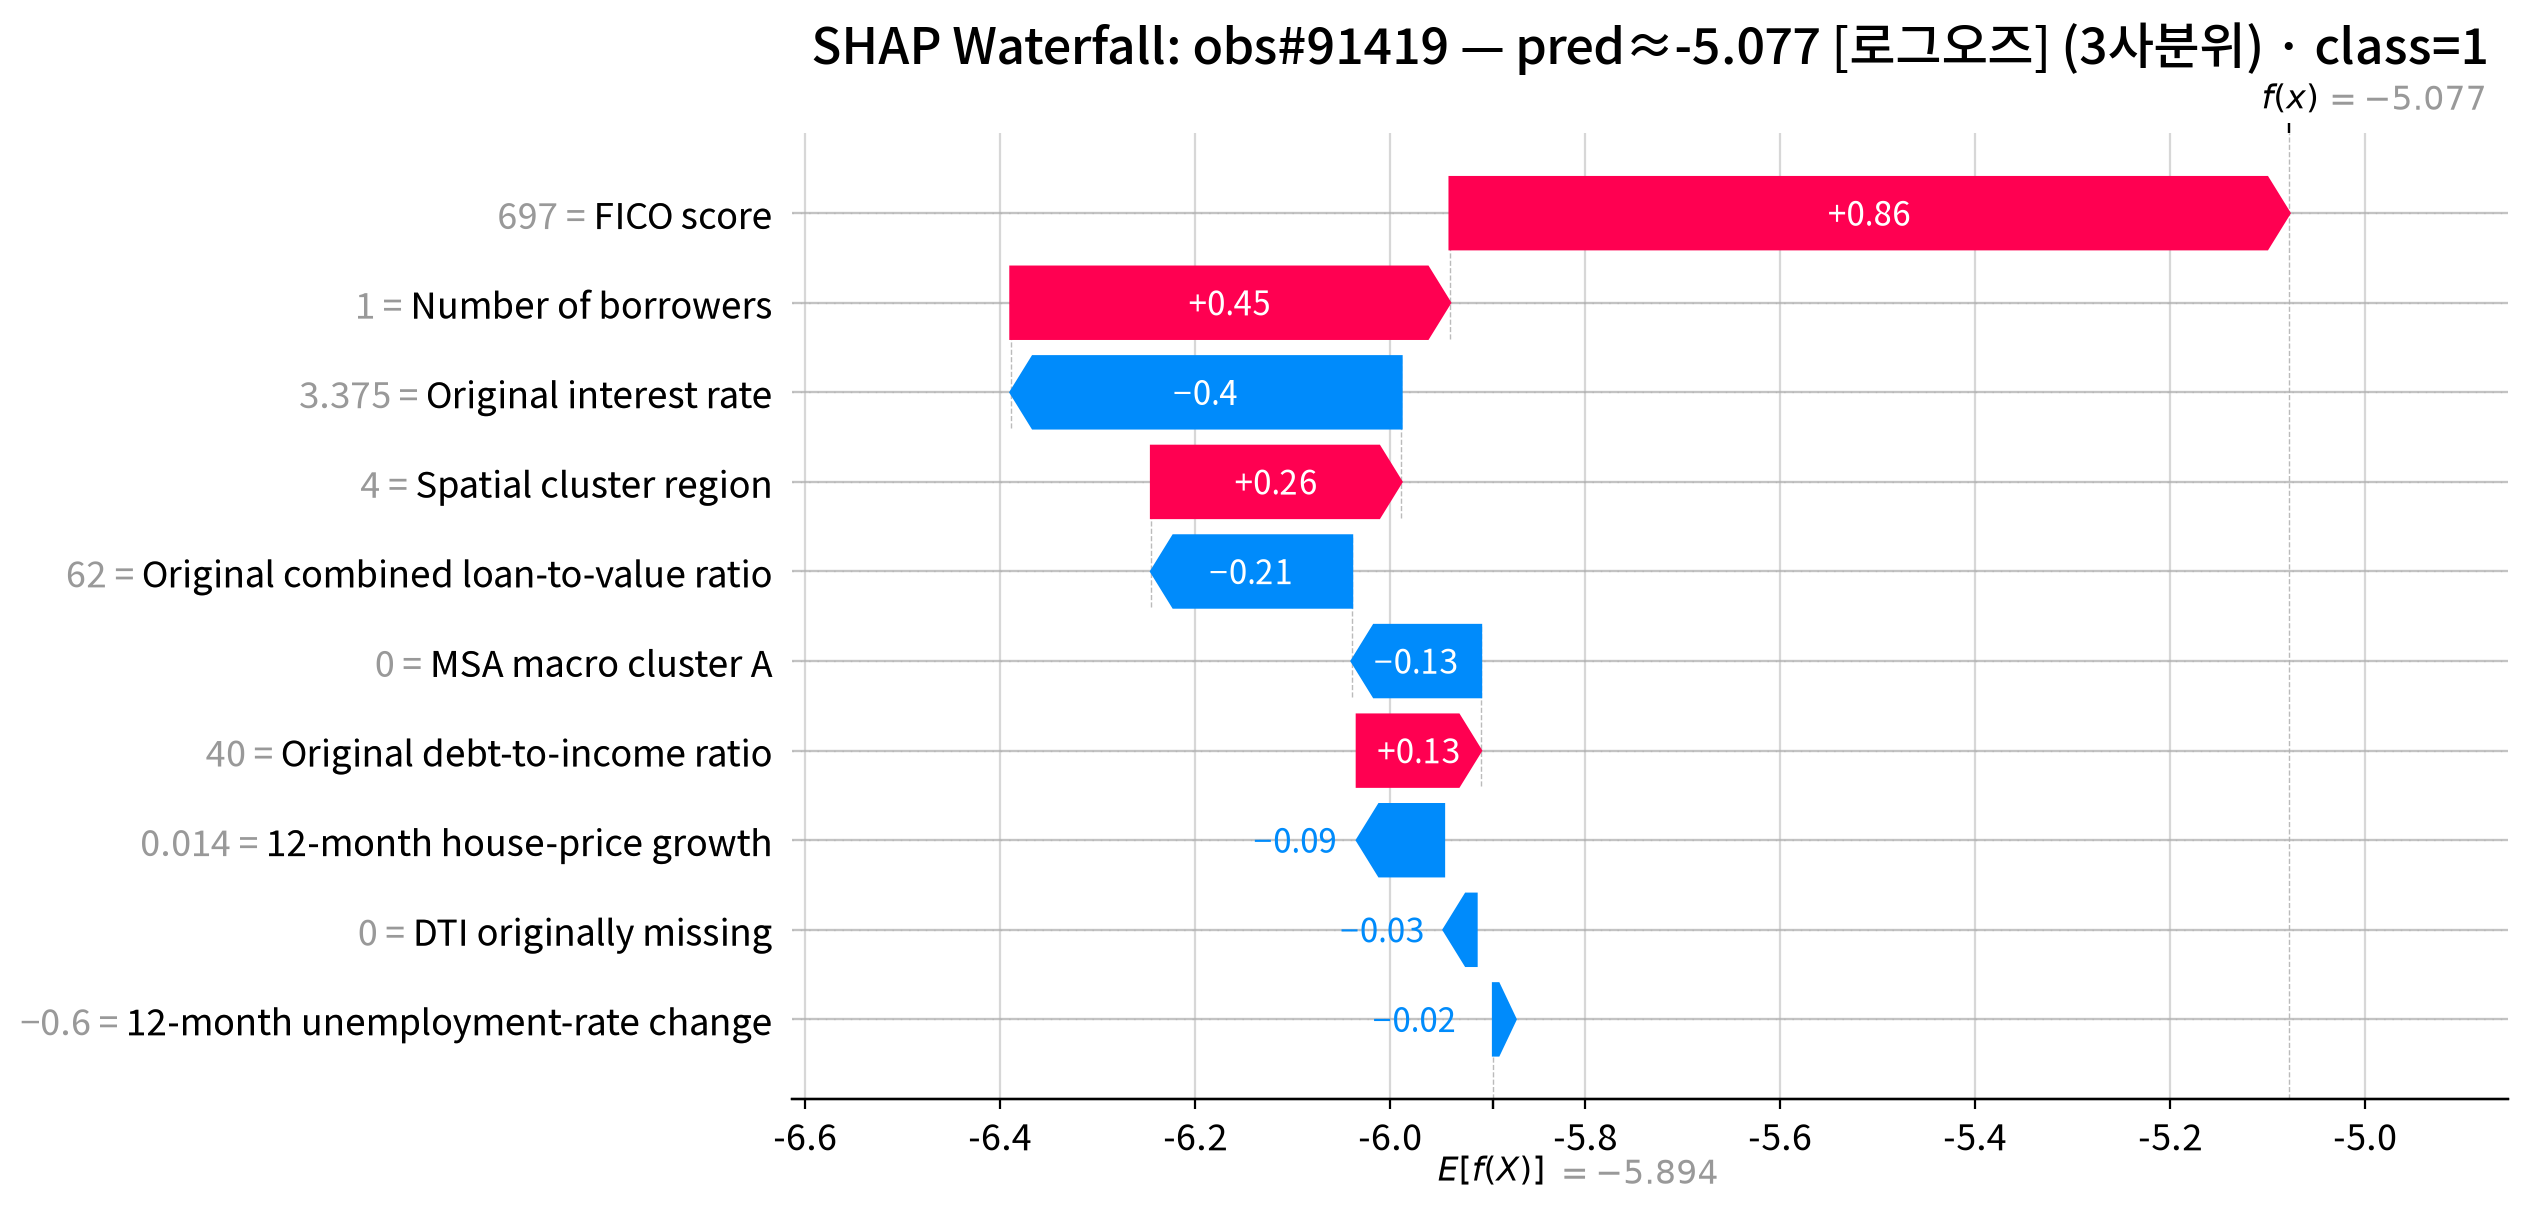

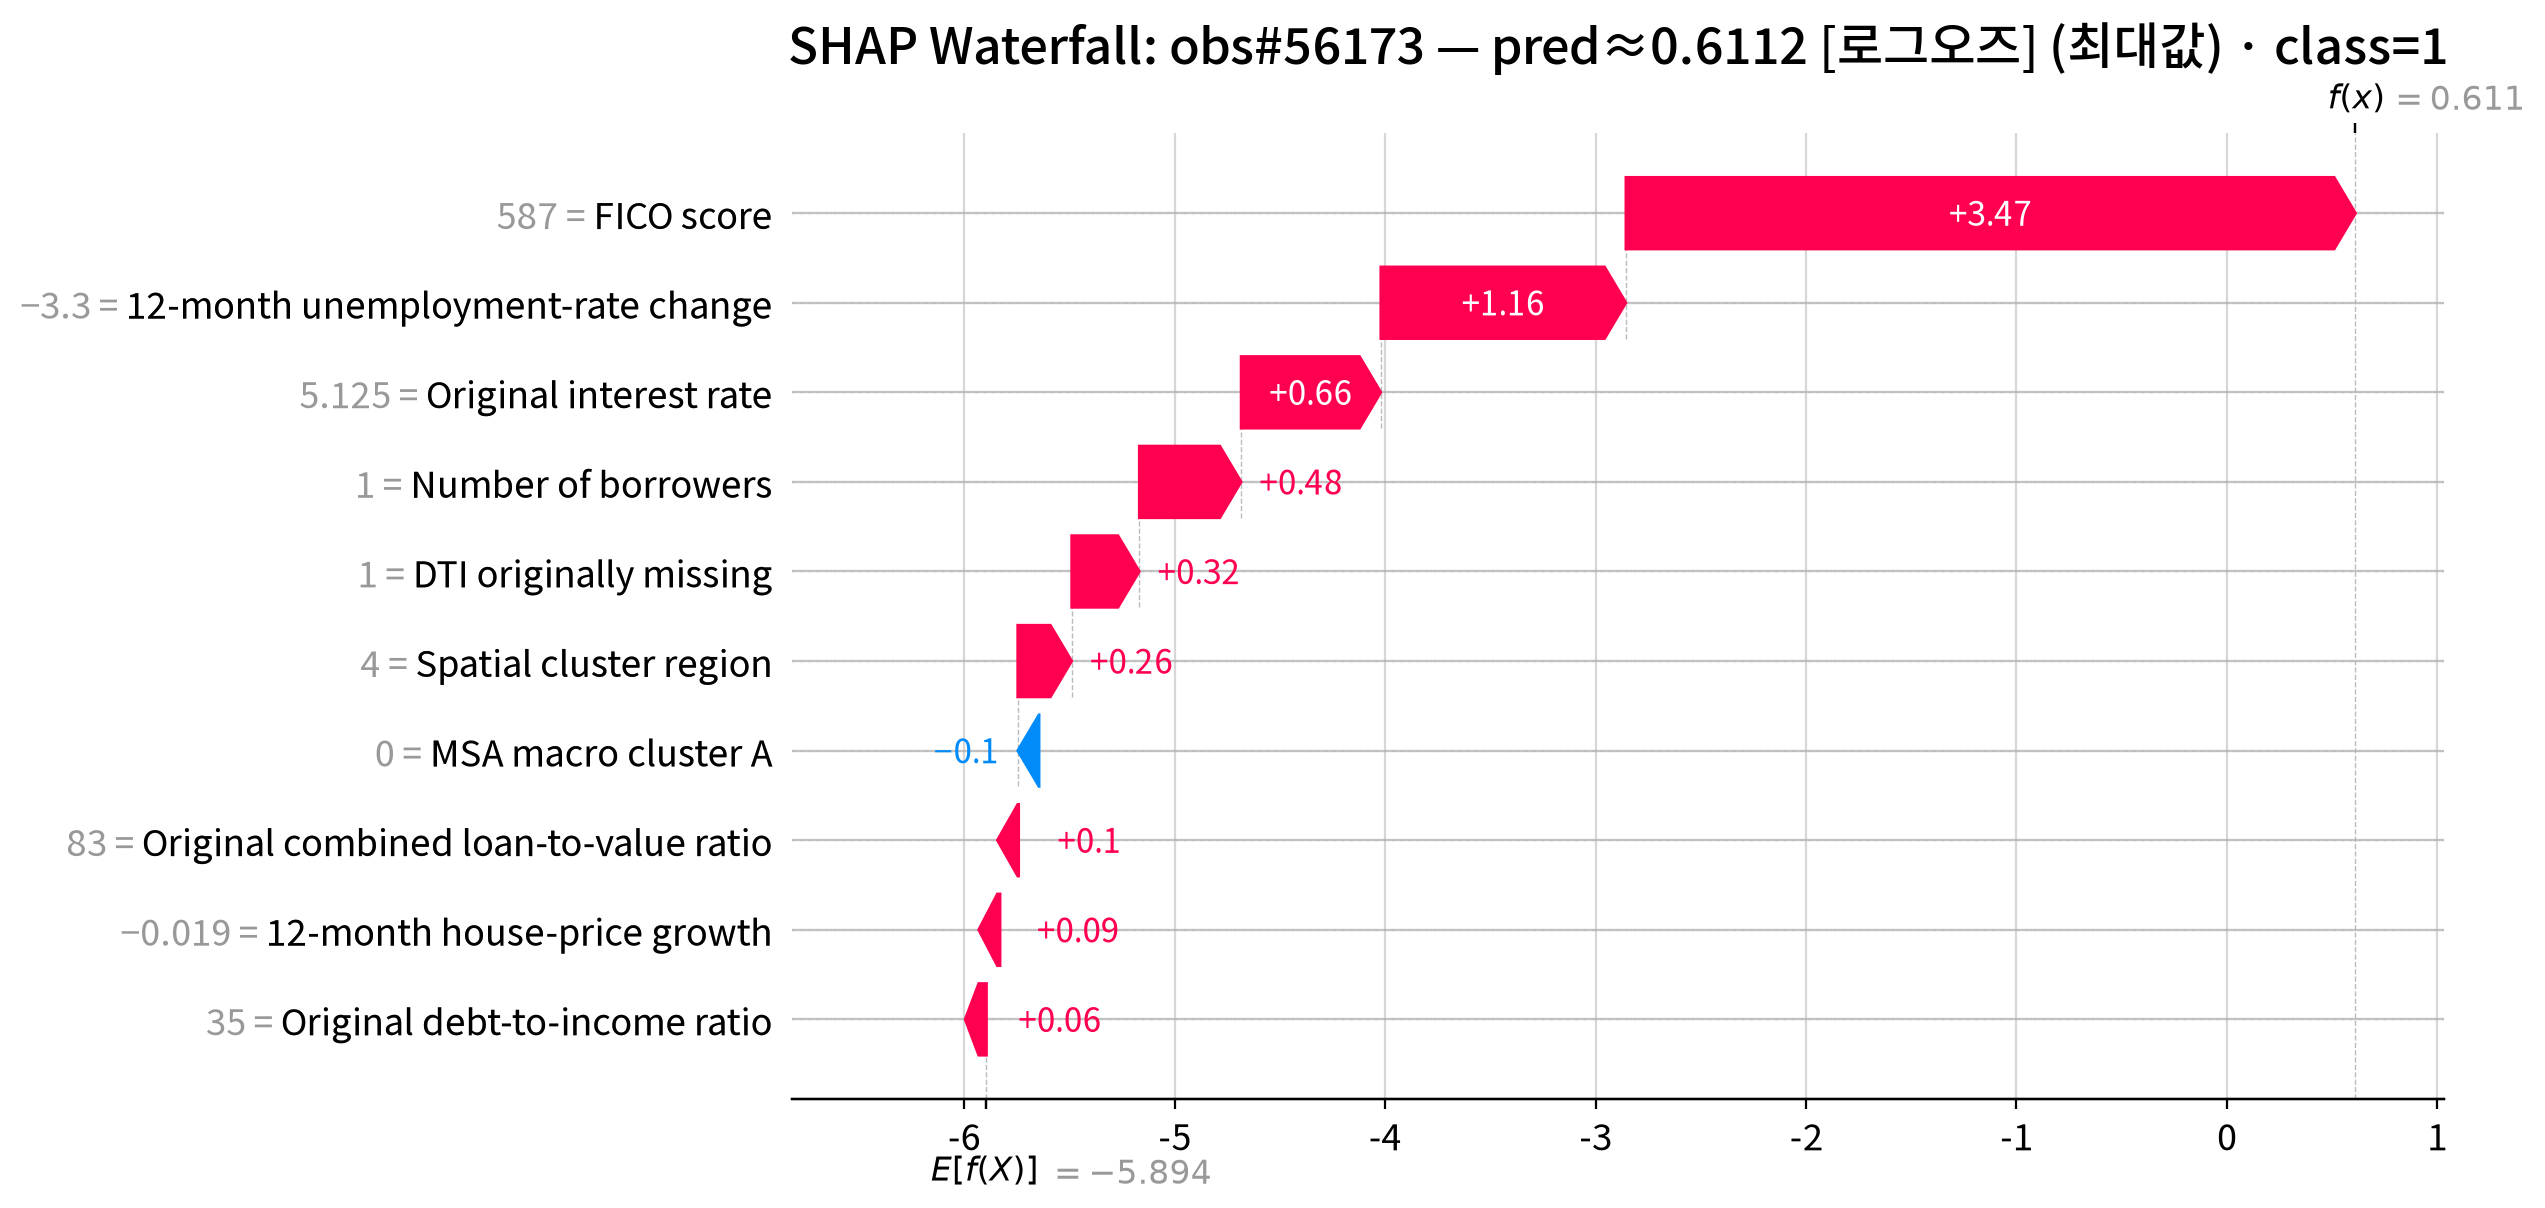

,stat,quantile,pred,proba,FICO_Score,Original_DTI,Original_CLTV,Original_Interest_Rate,Number_of_Borrowers,Housing_HPI_Growth_12M,BLS_Unemployment_Rate_Change_12M_Final,DTI_Missing,Spatial_Cluster_Region,Regular_MSA_Macro_Cluster_A
66609,최소값,0.000000,-9.329114,0.000089,795.0,12.0,27.0,2.875,2,0.033887,-1.2,0,1,0
98172,1사분위,0.249998,-6.770164,0.001146,754.0,43.0,65.0,4.125,2,0.053462,-0.8,0,2,0
92415,중앙값,0.500004,-5.924517,0.002666,784.0,35.0,73.0,4.625,1,0.042872,-1.3,0,6,1
132818,평균,0.509894,-5.893880,0.002749,752.0,21.0,90.0,4.125,1,0.000717,-0.9,0,6,1
79947,3사분위,0.750002,-5.077436,0.006197,697.0,40.0,62.0,3.375,1,0.013684,-0.6,0,4,0
7349,최대값,1.000000,0.611212,0.648217,587.0,35.0,83.0,5.125,1,-0.018655,-3.3,1,4,0


In [8]:
my_diag.shap_waterfall_stats_plot(
    summary, cum_ratio=cum_ratio, column_means=column_means,
)


In [9]:
# Probability summaries for selected continuous features; categorical features remain in the other SHAP plots.
my_diag.shap_proba_table(
    summary,
    bins={
        "FICO_Score": [300, 580, 620, 660, 700, 740, 780, 850],
        "Original_DTI": [0, 20, 30, 35, 40, 45, 50, 65],
        "Original_CLTV": [0, 60, 80, 90, 100, 120, 200],
    },
    inverse={},
    column_means=column_means,
)

base value: -5.8940 (로그오즈) → 확률 0.3% / 설명 대상 클래스: 1
proba·delta_pp = base 에 그 수준의 평균 SHAP 만 더했을 때의 확률과 base 대비 %p / step_dz·step_dpp = 같은 변수의 직전 수준과의 차이
 • n: 수준에 속한 관측치 수
 • ratio: 전체 관측치 대비 비율
 • mean_shap: 수준별 평균 SHAP
 • z: base + mean_shap
 • proba: 확률
 • delta_pp: base 대비 %p
 • step_dz: 직전 수준 대비 SHAP 변화
 • step_dpp: 직전 수준 대비 확률 변화 (%p)


n     ratio  \
Feature                               Level                                   
FICO score                            [300, 580]              440  0.003437   
                                      (580, 620]              764  0.005969   
                                      (620, 660]             5406  0.042234   
                                      (660, 700]            16132  0.126029   
                                      (700, 740]            27124  0.211903   
                                      (740, 780]            38098  0.297636   
                                      (780, 850]            40038  0.312792   
Number of borrowers                   1                     63458  0.495758   
                                      2                     64544  0.504242   
Original interest rate                [2.25, 3.625]         30538  0.238574   
                                      (3.625, 3.875]        21316  0.166529   
                                      (3.875, 4.25]         36527  0.285363   
                                      (4.25, 4.5]           18481  0.144381   
                                      (4.5, 5.875]          21140  0.165154   
Original combined loan-to-value ratio [0, 60]               24421  0.190786   
                                      (60, 80]              65409  0.511000   
                                      (80, 90]              16392  0.128060   
                                      (90, 100]             19103  0.149240   
                                      (100, 120]             1708  0.013344   
                                      (120, 200]              938  0.007328   
Original debt-to-income ratio         [0, 20]               11040  0.086249   
                                      (20, 30]              28924  0.225965   
                                      (30, 35]              32232  0.251809   
                                      (35, 40]              21747  0.169896   
                                      (40, 45]              25375  0.198239   
                                      (45, 50]               8684  0.067843   
Spatial cluster region                0                     24228  0.189278   
                                      1                     28524  0.222840   
                                      2                      7754  0.060577   
                                      3                     12752  0.099623   
                                      4                     20764  0.162216   
                                      5                       511  0.003992   
                                      6                     25639  0.200302   
                                      7                      7830  0.061171   
12-month unemployment-rate change     [-4.2, -1.3]          26542  0.207356   
                                      (-1.3, -0.9]          28580  0.223278   
                                      (-0.9, -0.7]          22629  0.176786   
                                      (-0.7, -0.3]          25407  0.198489   
                                      (-0.3, 2.7]           24844  0.194091   
MSA macro cluster A                   0                     62162  0.485633   
                                      1                     65840  0.514367   
DTI originally missing                0                    115162  0.899689   
                                      1                     12840  0.100311   
12-month house-price growth           [-0.09113, 0.02604]   25601  0.200005   
                                      (0.02604, 0.04361]    25600  0.199997   
                                      (0.04361, 0.0635]     25623  0.200177   
                                      (0.0635, 0.0898]      25688  0.200684   
                                      (0.0898, 0.294]       25490  0.199138   

                                                           mean_shap  \
Feature                               Lev

In [10]:
import numpy as np
import pandas as pd
from catboost import Pool

# The fitted CatBoost model inside the saved pipeline
catboost = estimator.named_steps["model"]

# Confirm that the model receives the same feature columns
model_features = list(catboost.feature_names_)
X_shap = x_train[model_features].copy()

cat_cols = [
    col for col in X_shap.columns
    if isinstance(X_shap[col].dtype, pd.CategoricalDtype)
]

# CatBoost SHAP: the last column is the expected value
pool = Pool(X_shap, cat_features=cat_cols)
shap_values = catboost.get_feature_importance(
    data=pool,
    type="ShapValues",
)

dti_position = model_features.index("Original_DTI")
dti_shap = shap_values[:, dti_position]

# Convert the categorical missing flag to numeric 0/1 for grouping
missing_flag = pd.to_numeric(
    X_shap["DTI_Missing"].astype(str),
    errors="raise",
).to_numpy()

dti_is_35 = np.isclose(
    pd.to_numeric(X_shap["Original_DTI"]).to_numpy(),
    35,
)

groups = {
    "Observed DTI = 35": dti_is_35 & (missing_flag == 0),
    "Imputed DTI = 35": dti_is_35 & (missing_flag == 1),
}

y_array = np.asarray(y_train)

rows = []
for name, mask in groups.items():
    values = dti_shap[mask]
    rows.append({
        "Group": name,
        "N": int(mask.sum()),
        "Events": int(y_array[mask].sum()),
        "Event_Rate_pct": 100 * y_array[mask].mean(),
        "DTI_SHAP_Mean": values.mean(),
        "DTI_SHAP_Median": np.median(values),
        "DTI_SHAP_P05": np.quantile(values, 0.05),
        "DTI_SHAP_P25": np.quantile(values, 0.25),
        "DTI_SHAP_P75": np.quantile(values, 0.75),
        "DTI_SHAP_P95": np.quantile(values, 0.95),
    })

comparison = pd.DataFrame(rows).set_index("Group")
display(comparison)

,N,Events,Event_Rate_pct,DTI_SHAP_Mean,DTI_SHAP_Median,DTI_SHAP_P05,DTI_SHAP_P25,DTI_SHAP_P75,DTI_SHAP_P95
Group,,,,,,,,,
Observed DTI = 35,3979,24,0.603167,0.080172,0.080781,0.067779,0.074844,0.085473,0.091057
Imputed DTI = 35,12840,203,1.580997,0.064416,0.064837,0.048261,0.058029,0.071211,0.078984


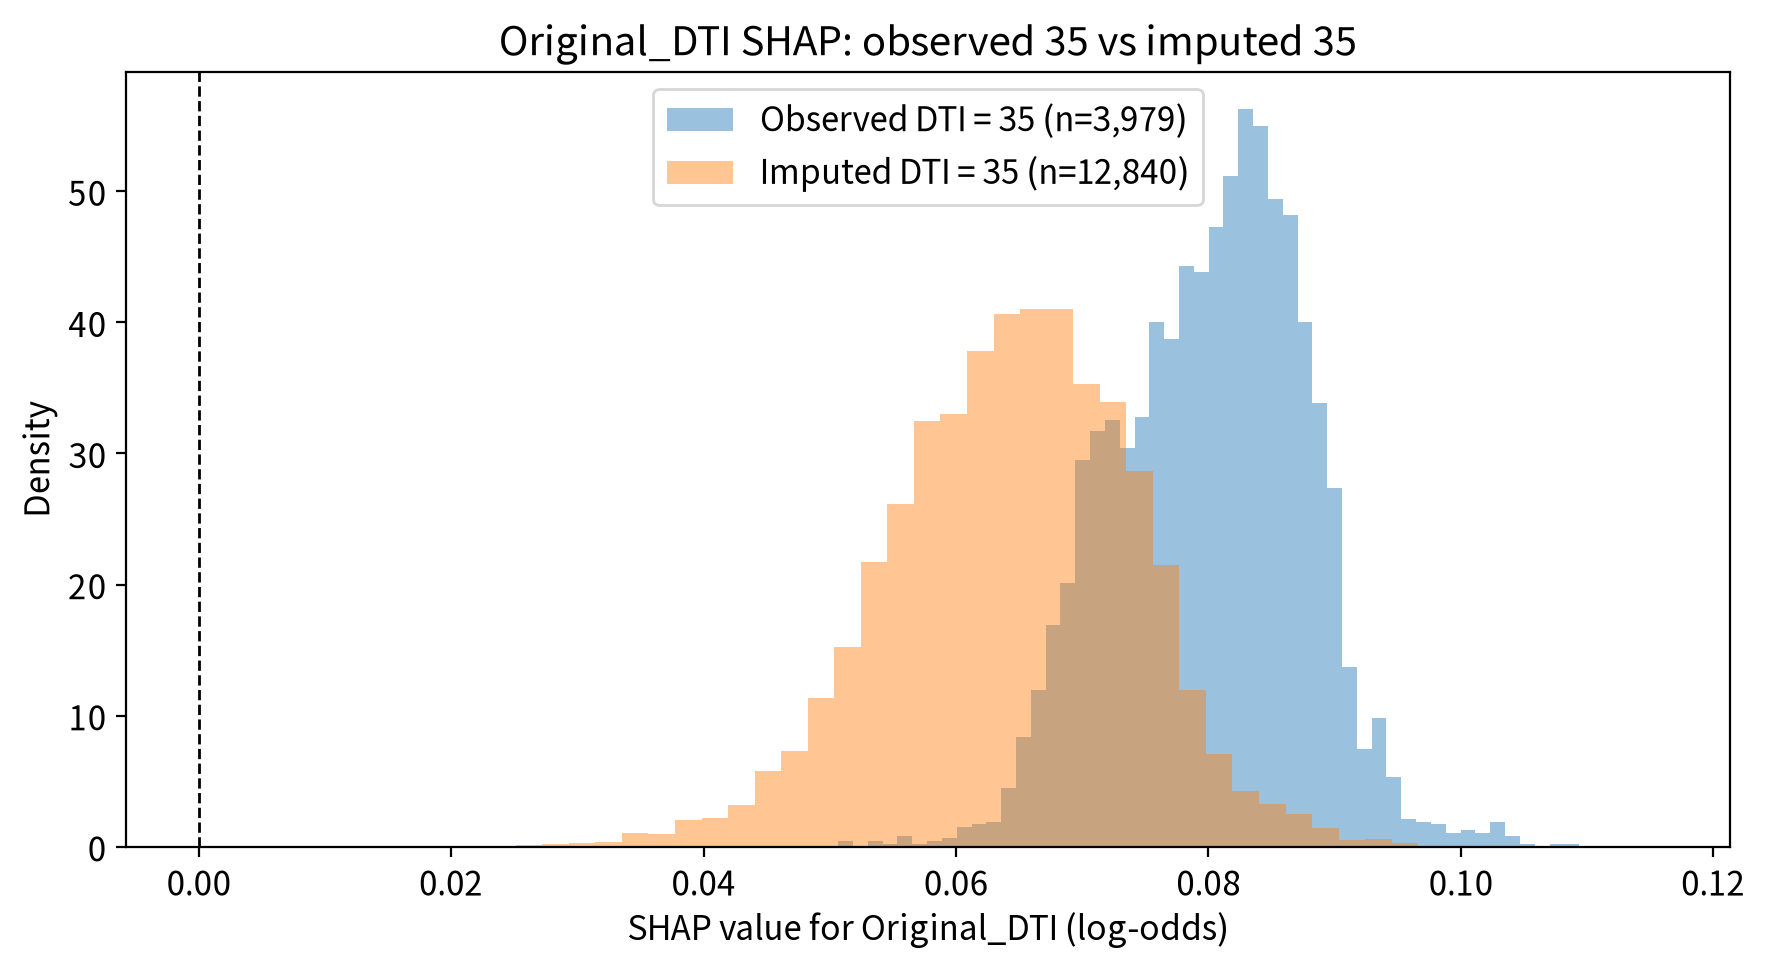

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

for name, mask in groups.items():
    plt.hist(
        dti_shap[mask],
        bins=50,
        density=True,
        alpha=0.45,
        label=f"{name} (n={mask.sum():,})",
    )

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("SHAP value for Original_DTI (log-odds)")
plt.ylabel("Density")
plt.title("Original_DTI SHAP: observed 35 vs imputed 35")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd
from catboost import Pool

catboost = estimator.named_steps["model"]
model_features = list(catboost.feature_names_)
missing_position = model_features.index("DTI_Missing")

def compare_dti_35(X, y, dataset_name):
    X_model = X[model_features].copy()
    y_array = np.asarray(y)

    missing_flag = pd.to_numeric(
        X_model["DTI_Missing"].astype(str),
        errors="raise",
    ).to_numpy()

    dti_is_35 = np.isclose(
        pd.to_numeric(X_model["Original_DTI"]).to_numpy(),
        35,
    )

    cat_cols = [
        col for col in X_model.columns
        if isinstance(X_model[col].dtype, pd.CategoricalDtype)
    ]

    shap_values = catboost.get_feature_importance(
        Pool(X_model, cat_features=cat_cols),
        type="ShapValues",
    )
    missing_shap = shap_values[:, missing_position]

    # Use the complete saved pipeline for predicted probabilities
    predicted_probability = estimator.predict_proba(X_model)[:, 1]

    groups = {
        "Observed DTI = 35": dti_is_35 & (missing_flag == 0),
        "Imputed DTI = 35": dti_is_35 & (missing_flag == 1),
    }

    rows = []
    for group_name, mask in groups.items():
        if not mask.any():
            continue

        rows.append({
            "Dataset": dataset_name,
            "Group": group_name,
            "N": int(mask.sum()),
            "Events": int(y_array[mask].sum()),
            "Actual_Event_Rate_pct": 100 * y_array[mask].mean(),
            "Mean_Predicted_Probability_pct":
                100 * predicted_probability[mask].mean(),
            "DTI_Missing_SHAP_Mean": missing_shap[mask].mean(),
            "DTI_Missing_SHAP_Median": np.median(missing_shap[mask]),
            "DTI_Missing_SHAP_P05": np.quantile(missing_shap[mask], 0.05),
            "DTI_Missing_SHAP_P95": np.quantile(missing_shap[mask], 0.95),
        })

    return pd.DataFrame(rows)

result = pd.concat(
    [
        compare_dti_35(x_train, y_train, "Train"),
        compare_dti_35(x_test, y_test, "Test"),
    ],
    ignore_index=True,
)

display(result)

,Dataset,Group,N,Events,Actual_Event_Rate_pct,Mean_Predicted_Probability_pct,DTI_Missing_SHAP_Mean,DTI_Missing_SHAP_Median,DTI_Missing_SHAP_P05,DTI_Missing_SHAP_P95
0,Train,Observed DTI = 35,3979,24,0.603167,0.512237,-0.038855,-0.038839,-0.044558,-0.033418
1,Train,Imputed DTI = 35,12840,203,1.580997,1.535451,0.347707,0.352835,0.293226,0.391854
2,Test,Observed DTI = 35,1037,6,0.578592,0.486743,-0.038951,-0.038824,-0.044706,-0.033250
3,Test,Imputed DTI = 35,3161,47,1.486871,1.457547,0.348968,0.353634,0.294176,0.393134
